In [1]:
import pandas as pd
import numpy as np
from millify import millify
from IPython.display import HTML,display
import matplotlib.pyplot as plt
from itertools import combinations

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
order_item_refunds=pd.read_csv("order_item_refunds.csv",parse_dates=["created_at"])
order_items=pd.read_csv("order_items.csv",parse_dates=["created_at"])
website_pageviews=pd.read_csv("website_pageviews.csv",parse_dates=["created_at"])
website_sessions=pd.read_csv("website_sessions.csv",parse_dates=["created_at"])
orders=pd.read_csv("orders.csv",parse_dates=["created_at"])
products=pd.read_csv("products.csv",parse_dates=["created_at"])

### all tables head for quick analysis

In [4]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "order_item_refunds": order_item_refunds,
    "website_sessions": website_sessions,
    "website_pageviews": website_pageviews,
    "products": products
}

for name, df in tables.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")
    display(df.head())


orders
Shape: (32313, 8)


,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49



order_items
Shape: (40025, 7)


,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49



order_item_refunds
Shape: (1731, 5)


...

,Unnamed: 0,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,year,quarter,channel
0,0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,2012Q1,gsearch
1,1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,2012Q1,gsearch
2,2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,2012Q1,gsearch
3,3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,2012Q1,gsearch
4,4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,2012Q1,gsearch



website_pageviews
Shape: (1188124, 4)


,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home



products
Shape: (4, 3)


,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [5]:
website_sessions.utm_source.unique()

array(['gsearch', nan, 'bsearch', 'socialbook'], dtype=object)

### extracting no of rows each table have

In [6]:
for name,df in tables.items():
    print(f"{name}: {df.shape[0]} rows")

orders: 32313 rows
order_items: 40025 rows
order_item_refunds: 1731 rows
website_sessions: 472871 rows
website_pageviews: 1188124 rows
products: 4 rows


### extracting columns for eda

In [7]:
for name,df in tables.items():
    print(f"\n{name} columns:")
    print(df.columns.tolist())


orders columns:
['order_id', 'created_at', 'website_session_id', 'user_id', 'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd']

order_items columns:
['order_item_id', 'created_at', 'order_id', 'product_id', 'is_primary_item', 'price_usd', 'cogs_usd']

order_item_refunds columns:
['order_item_refund_id', 'created_at', 'order_item_id', 'order_id', 'refund_amount_usd']

website_sessions columns:
['Unnamed: 0', 'website_session_id', 'created_at', 'user_id', 'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content', 'device_type', 'http_referer', 'year', 'quarter', 'channel']

website_pageviews columns:
['website_pageview_id', 'created_at', 'website_session_id', 'pageview_url']

products columns:
['product_id', 'created_at', 'product_name']


In [8]:
type(products)

pandas.core.frame.DataFrame

In [9]:
products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [10]:
products['product_name'].unique()

array(['The Original Mr. Fuzzy', 'The Forever Love Bear',
       'The Birthday Sugar Panda', 'The Hudson River Mini bear'],
      dtype=object)

In [11]:
website_sessions.utm_source.isnull().sum()

np.int64(83328)

In [12]:
website_sessions.groupby('utm_source')['website_session_id'].size()

utm_source
bsearch        62823
gsearch       316035
socialbook     10685
Name: website_session_id, dtype: int64

### checking data consistency

In [13]:
orders_total_revenue = orders['price_usd'].sum()
print(millify(orders_total_revenue,precision = 2))

1.94M


In [14]:
order_items_total_revenue = order_items['price_usd'].sum()
print(millify(order_items_total_revenue,precision = 2))

1.94M


“Order-level revenue matches the sum of item-level revenue, confirming data consistency.”

## profit orders and revenue

In [15]:
orders['order_month']=orders['created_at'].dt.to_period('M')

In [16]:
df=orders.groupby('order_month')[['price_usd','cogs_usd','items_purchased']].sum().reset_index()
df['profit_margin']=df['price_usd']-df['cogs_usd']
df.columns=['month_year','revenue','cost','item_sold','profit_margin']
df['year']=df['month_year'].dt.year
df

,month_year,revenue,cost,item_sold,profit_margin,year
0,2012-03,2999.40,1169.40,60,1830.0,2012
1,2012-04,4949.01,1929.51,99,3019.5,2012
2,2012-05,5398.92,2104.92,108,3294.0,2012
3,2012-06,6998.60,2728.60,140,4270.0,2012
4,2012-07,8448.31,3293.81,169,5154.5,2012
5,2012-08,11397.72,4443.72,228,6954.0,2012
6,2012-09,14347.13,5593.63,287,8753.5,2012
7,2012-10,18546.29,7230.79,371,11315.5,2012
8,2012-11,30893.82,12044.82,618,18849.0,2012
9,2012-12,25294.94,9861.94,506,15433.0,2012


In [17]:
df.groupby('year')[['revenue','cost','item_sold','profit_margin']].sum().reset_index()

,year,revenue,cost,item_sold,profit_margin
0,2012,129274.14,50401.14,2586,78873.0
1,2013,393247.87,151651.37,7613,241596.5
2,2014,1075612.19,395889.69,22581,679722.5
3,2015,340375.55,124428.05,7245,215947.5


## total orders vs visitors vs sessions

In [18]:
orders['year'] = orders['created_at'].dt.year
website_sessions['year'] = website_sessions['created_at'].dt.year

In [19]:
# Year-wise Orders
yearly_orders = (
    orders.groupby('year')['order_id']
    .nunique()
    .reset_index(name='orders')
)
yearly_orders

,year,orders
0,2012,2586
1,2013,7447
2,2014,16860
3,2015,5420


In [20]:
# Year-wise Sessions
yearly_sessions = (
    website_sessions.groupby('year')['website_session_id']
    .nunique()
    .reset_index(name='sessions')
)
yearly_sessions

,year,sessions
0,2012,62470
1,2013,112781
2,2014,233422
3,2015,64198


In [21]:
# Year-wise Visitors
yearly_visitors = (
    website_sessions.groupby('year')['user_id']
    .nunique()
    .reset_index(name='visitors')
)
yearly_visitors

,year,visitors
0,2012,56543
1,2013,97809
2,2014,193958
3,2015,55534


## quarterly basis revenue per session

In [22]:
orders['quarter']=orders['created_at'].dt.to_period('Q')
website_sessions['quarter']=website_sessions['created_at'].dt.to_period('Q')

In [23]:
# quarterly revenue
quarterly_revenue= orders.groupby('quarter')['price_usd'].sum().reset_index(name= 'revenue')
# quarterly sessions
quarterly_sessions= website_sessions.groupby('quarter')['website_session_id'].nunique().reset_index(name='sessions')


In [24]:
# merging two data sets
quarterly_avg_price_per_session=quarterly_revenue.merge(
    quarterly_sessions,on='quarter')
quarterly_avg_price_per_session['avg_price_per_sessions']=(quarterly_avg_price_per_session['revenue']
                                                           /quarterly_avg_price_per_session['sessions'])
quarterly_avg_price_per_session[['quarter','avg_price_per_sessions']]

,quarter,avg_price_per_sessions
0,2012Q1,1.596275
1,2012Q2,1.517233
2,2012Q3,2.024222
3,2012Q4,2.316217
4,2013Q1,3.346809
5,2013Q2,3.576190
6,2013Q3,3.442921
7,2013Q4,3.530741
8,2014Q1,4.078136
9,2014Q2,4.662462


In [25]:
website_sessions.columns

Index(['Unnamed: 0', 'website_session_id', 'created_at', 'user_id',
       'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content',
       'device_type', 'http_referer', 'year', 'quarter', 'channel'],
      dtype='object')

# creating channel

In [26]:
# creating channel
website_sessions['channel'] = None

# paid traffic
website_sessions.loc[
    website_sessions['utm_source'].notna(),'channel'
]=website_sessions['utm_source']

# organic traffic
website_sessions.loc[(website_sessions['utm_source'].isna()) &
                     (website_sessions['http_referer'].notna()),'channel']= 'organic'

# direct traffic
website_sessions.loc[
    (website_sessions['utm_source'].isna()) &
    (website_sessions['http_referer'].isna())
    ,'channel'] = 'direct'

## direct type order trend

In [27]:
orders_sessions=orders.merge(website_sessions[['website_session_id', 'channel']],
                            on = 'website_session_id', how= 'left')
direct_orders = orders_sessions[orders_sessions['channel'] == 'direct']
direct_orders_trend = (
    direct_orders
    .groupby('quarter')['order_id']
    .nunique()
    .reset_index(name='direct_orders')
)

direct_orders_trend

,quarter,direct_orders
0,2012Q2,21
1,2012Q3,32
2,2012Q4,89
3,2013Q1,91
4,2013Q2,119
5,2013Q3,143
6,2013Q4,197
7,2014Q1,311
8,2014Q2,367
9,2014Q3,402


## organic search orders trend

In [28]:
organic_orders = orders_sessions[
    (orders_sessions['channel']=='organic')
]
organic_orders_trend = (
    organic_orders
    .groupby('quarter')['order_id']
    .nunique()
    .reset_index(name='organic_orders')
)

organic_orders_trend

,quarter,organic_orders
0,2012Q2,15
1,2012Q3,40
2,2012Q4,94
3,2013Q1,125
4,2013Q2,134
5,2013Q3,167
6,2013Q4,223
7,2014Q1,338
8,2014Q2,436
9,2014Q3,445


In [29]:
direct_organic_trend= direct_orders_trend.merge(
    organic_orders_trend,on= 'quarter',how = 'inner')
direct_organic_trend

,quarter,direct_orders,organic_orders
0,2012Q2,21,15
1,2012Q3,32,40
2,2012Q4,89,94
3,2013Q1,91,125
4,2013Q2,119,134
5,2013Q3,143,167
6,2013Q4,197,223
7,2014Q1,311,338
8,2014Q2,367,436
9,2014Q3,402,445


In [30]:
orders_sessions.shape

(32313, 12)

# Session to order conversion rate analysis : Gsearch, Bsearch, Brand , Organic and direct

In [31]:
website_sessions.utm_campaign.unique()

array(['nonbrand', nan, 'brand', 'pilot', 'desktop_targeted'],
      dtype=object)

In [32]:
# creating channel group
website_sessions['channel_group'] = None

# direct 
website_sessions.loc[
    website_sessions['channel']=='direct','channel_group'
] = 'Direct Type-in'

# organic search
website_sessions.loc[website_sessions['channel'] == 'organic','channel_group'
] = 'Organic Search'

# brand
website_sessions.loc[
    website_sessions['utm_campaign']=='brand','channel_group'
] = 'Brand Search'

# GSearch Nonbrand
website_sessions.loc[
    (website_sessions['utm_source']=='gsearch') &
    (website_sessions['utm_campaign']=='nonbrand'),'channel_group'
] = 'GSearch Nonbrand'

# BSearch Nonbrand
website_sessions.loc[
    (website_sessions['utm_source']=='bsearch') &
    (website_sessions['utm_campaign'] == 'nonbrand'), 'channel_group'
] = 'BSearch Nonbrand'

In [33]:
channel_group = website_sessions[website_sessions['channel_group'].notna()]
sessions= channel_group.groupby(['quarter','channel_group'])['website_session_id'].nunique().reset_index(name='sessions')
orders_count=( channel_group.merge(orders[['order_id','website_session_id']], on='website_session_id')
              .groupby(['quarter','channel_group'])['order_id'].nunique().reset_index(name='orders')
)
final= sessions.merge(orders_count,on= ['quarter','channel_group'],how='left' )
final['orders']=final['orders'].fillna(0)
final['CVR'] = final['orders'] / final['sessions'] *100
final.pivot(index = 'quarter',
            columns= 'channel_group',
            values='CVR').reset_index()

channel_group,quarter,BSearch Nonbrand,Brand Search,Direct Type-in,GSearch Nonbrand,Organic Search
0,2012Q1,NaN,0.000000,0.000000,3.239741,0.000000
1,2012Q2,NaN,5.263158,5.357143,2.840965,3.588517
2,2012Q3,4.081633,6.015038,4.432133,3.837580,4.981320
3,2012Q4,4.968051,5.314010,5.371153,4.358203,5.389908
4,2013Q1,6.926571,7.031250,6.140351,6.122123,7.525587
5,2013Q2,6.903583,6.785714,7.354759,6.854963,7.600681
6,2013Q3,6.968146,7.031250,7.185930,6.393674,7.337434
7,2013Q4,6.006192,8.007749,6.467498,6.291290,6.938395
8,2014Q1,7.039083,8.394593,7.652559,6.932834,7.559830
9,2014Q2,6.949870,8.036064,7.379851,7.022454,7.973665


# monthly growth trends for gsearch sessions and orders

In [34]:
website_sessions['month']=website_sessions['created_at'].dt.month
filter_df= website_sessions[website_sessions['utm_source']=='gsearch']
sessions= filter_df.groupby(['year','month'])['website_session_id'].nunique().reset_index(name='sessions')
orders_count = filter_df.merge(
    orders[['website_session_id','order_id']]
).groupby(['year','month'])['order_id'].nunique().reset_index(name='orders')
final= sessions.merge(orders_count, on=['year','month'],how= 'left')
final

,year,month,sessions,orders
0,2012,3,1860,60
1,2012,4,3574,92
2,2012,5,3410,97
3,2012,6,3578,121
4,2012,7,3811,145
5,2012,8,4877,184
6,2012,9,4491,188
7,2012,10,5534,234
8,2012,11,9715,417
9,2012,12,7038,333


# Monthly trend Analysis: Brand vs non-brand campaign performance in gsearch

In [35]:
sessions = filter_df.groupby(['year','month','utm_campaign'])['website_session_id'].nunique().reset_index(name='sessions')
order_count= filter_df.merge(
    orders[['order_id','website_session_id']],on='website_session_id'
).groupby(['year','month','utm_campaign'])['order_id'].nunique().reset_index(name='orders')
session_count= sessions.pivot(
    index=['year','month'],
    columns='utm_campaign',
    values='sessions'
)
session_count

utm_campaign  brand  nonbrand
year month                   
2012 3            8      1852
     4           65      3509
     5          115      3295
     6          139      3439
     7          151      3660
     8          204      4673
     9          264      4227
     10         337      5197
     11         458      9257
     12         543      6495
2013 1          516      3691
     2          382      4742
     3          354      4079
     4          400      5341
     5          476      5508
     6          471      5402
     7          589      5654
     8          580      5877
     9          591      6174
     10         692      6828
     11         777      9488
     12        1038     10022
2014 1         1107      7500
     2         1090      8223
     3         1187      8322
     4         1328     10309
     5         1383     10699
     6         1425     10434
     7         1510     11125
     8         1548     10450
     9         1567     10567
     10        1769     11450
     11        1893     13936
     12        2438     16139
2015 1         2362     13726
     2         2156     13034
     3         1416      8382

In [36]:
order_counts=order_count.pivot(
     index=['year','month'],
    columns='utm_campaign',
    values='orders'
)
order_counts

utm_campaign  brand  nonbrand
year month                   
2012 3          NaN      60.0
     4          6.0      86.0
     5          6.0      91.0
     6          7.0     114.0
     7          9.0     136.0
     8         10.0     174.0
     9         16.0     172.0
     10        15.0     219.0
     11        21.0     396.0
     12        35.0     298.0
2013 1         31.0     213.0
     2         39.0     302.0
     3         17.0     251.0
     4         32.0     366.0
     5         26.0     364.0
     6         38.0     384.0
     7         34.0     359.0
     8         43.0     381.0
     9         46.0     392.0
     10        53.0     451.0
     11        55.0     574.0
     12        81.0     632.0
2014 1         91.0     543.0
     2         84.0     556.0
     3         95.0     568.0
     4        116.0     703.0
     5        105.0     806.0
     6        103.0     699.0
     7        110.0     747.0
     8        122.0     752.0
     9        108.0     760.0
     10       152.0     813.0
     11       144.0    1111.0
     12       176.0    1324.0
2015 1        192.0    1156.0
     2        181.0    1159.0
     3        112.0     710.0

# nonbrand gsearch: monthly sessions & orders by device type

In [37]:
website_sessions['month'] = website_sessions.created_at.dt.month

In [38]:
filtered_df= website_sessions[
    (website_sessions['utm_source']=='gsearch') &
    (website_sessions['utm_campaign']=='nonbrand')
]
sessions=filtered_df.groupby(['year','month','device_type'])['website_session_id'].nunique().reset_index(name='sessions')
sessions.pivot(
    index=['year','month'],
    columns= 'device_type',
    values='sessions'
)

device_type  desktop  mobile
year month                  
2012 3          1128     724
     4          2139    1370
     5          2276    1019
     6          2673     766
     7          2774     886
     8          3515    1158
     9          3171    1056
     10         3934    1263
     11         7007    2250
     12         4947    1548
2013 1          2795     896
     2          3603    1139
     3          3082     997
     4          4058    1283
     5          4247    1261
     6          4093    1309
     7          4328    1326
     8          4174    1703
     9          3991    2183
     10         4482    2346
     11         6124    3364
     12         6552    3470
2014 1          4948    2552
     2          5393    2830
     3          5453    2869
     4          6729    3580
     5          6819    3880
     6          6760    3674
     7          7248    3877
     8          6818    3632
     9          6828    3739
     10         7473    3977
     11         9650    4286
     12        11291    4848
2015 1          9596    4130
     2          9130    3904
     3          5926    2456

In [39]:
df=filtered_df.merge(orders[['order_id','website_session_id']],on='website_session_id')
order_count=df.groupby(['year','month','device_type'])['order_id'].nunique().reset_index(name='orders')
order_count.pivot(
    index=['year','month'],
    columns= 'device_type',
    values= 'orders'
)

device_type  desktop  mobile
year month                  
2012 3            50      10
     4            75      11
     5            83       8
     6           106       8
     7           122      14
     8           165       9
     9           155      17
     10          201      18
     11          354      42
     12          282      16
2013 1           190      23
     2           271      31
     3           224      27
     4           335      31
     5           321      43
     6           351      33
     7           316      43
     8           321      60
     9           329      63
     10          385      66
     11          461     113
     12          505     127
2014 1           451      92
     2           454     102
     3           471      97
     4           558     145
     5           649     157
     6           566     133
     7           609     138
     8           626     126
     9           631     129
     10          686     127
     11          973     138
     12         1128     196
2015 1           999     157
     2          1007     152
     3           627      83

# Monthly Trend Analysis of Traffic Source

In [40]:
website_sessions.utm_source.unique()

array(['gsearch', nan, 'bsearch', 'socialbook'], dtype=object)

In [41]:
df=website_sessions.merge(orders[['order_id','website_session_id']],on='website_session_id')
order_trend=df.groupby(['year','month','utm_source'],dropna=False)['order_id'].nunique().reset_index(name='orders')
order_trend.pivot(
    index=['year','month'],
    columns='utm_source',
    values='orders'
).fillna(0)

utm_source    NaN  bsearch  gsearch  socialbook
year month                                     
2012 3        0.0      0.0     60.0         0.0
     4        7.0      0.0     92.0         0.0
     5       11.0      0.0     97.0         0.0
     6       18.0      1.0    121.0         0.0
     7       22.0      2.0    145.0         0.0
     8       25.0     19.0    184.0         0.0
     9       25.0     74.0    188.0         0.0
     10      48.0     89.0    234.0         0.0
     11      51.0    150.0    417.0         0.0
     12      84.0     89.0    333.0         0.0
2013 1       84.0     63.0    244.0         0.0
     2       80.0     76.0    341.0         0.0
     3       52.0     65.0    268.0         0.0
     4       74.0     81.0    398.0         0.0
     5       95.0     86.0    390.0         0.0
     6       84.0     88.0    422.0         0.0
     7      113.0     97.0    393.0         0.0
     8       93.0     91.0    424.0         0.0
     9      104.0     87.0    438.0         0.0
     10     115.0     89.0    504.0         0.0
     11     123.0    109.0    629.0         0.0
     12     182.0    152.0    713.0         0.0
2014 1      194.0    138.0    634.0        17.0
     2      227.0    130.0    640.0        24.0
     3      228.0    160.0    663.0        14.0
     4      269.0    153.0    819.0         0.0
     5      281.0    176.0    911.0         0.0
     6      253.0    184.0    802.0         0.0
     7      274.0    156.0    857.0         0.0
     8      267.0    169.0    874.0        14.0
     9      306.0    201.0    868.0        49.0
     10     360.0    229.0    965.0        55.0
     11     357.0    291.0   1255.0        82.0
     12     420.0    306.0   1500.0        88.0
2015 1      485.0    266.0   1348.0         0.0
     2      434.0    293.0   1340.0         0.0
     3      273.0    159.0    822.0         0.0

# Cross Selling Analysis(When a customer buys Product A, how often do they also buy Product B in the same order?)

In [42]:
# merge data set to get producct name
df= order_items.merge(products, on = 'product_id', how = 'left')

In [43]:
primary=df[df['is_primary_item']== 1]
cross = df[df['is_primary_item']== 0]

In [44]:
pairs = primary.merge(cross, on = "order_id", suffixes=('_primary', '_cross'))
pairs = pairs[['order_id', 'product_name_primary', 'product_name_cross']]
pairs

,order_id,product_name_primary,product_name_cross
0,7300,The Original Mr. Fuzzy,The Forever Love Bear
1,7302,The Original Mr. Fuzzy,The Forever Love Bear
2,7310,The Original Mr. Fuzzy,The Forever Love Bear
3,7352,The Forever Love Bear,The Original Mr. Fuzzy
4,7376,The Original Mr. Fuzzy,The Forever Love Bear
...,...,...,...
7707,32296,The Original Mr. Fuzzy,The Birthday Sugar Panda
7708,32298,The Original Mr. Fuzzy,The Hudson River Mini bear
7709,32299,The Original Mr. Fuzzy,The Birthday Sugar Panda
7710,32304,The Birthday Sugar Panda,The Hudson River Mini bear


In [45]:
pair_counts = (
    pairs
    .groupby(['product_name_primary', 'product_name_cross'])
    .order_id
    .nunique().reset_index(name='cross_orders')
)
pair_counts

,product_name_primary,product_name_cross,cross_orders
0,The Birthday Sugar Panda,The Forever Love Bear,112
1,The Birthday Sugar Panda,The Hudson River Mini bear,640
2,The Birthday Sugar Panda,The Original Mr. Fuzzy,277
3,The Forever Love Bear,The Birthday Sugar Panda,136
4,The Forever Love Bear,The Hudson River Mini bear,671
5,The Forever Love Bear,The Original Mr. Fuzzy,72
6,The Hudson River Mini bear,The Birthday Sugar Panda,22
7,The Hudson River Mini bear,The Forever Love Bear,9
8,The Hudson River Mini bear,The Original Mr. Fuzzy,16
9,The Original Mr. Fuzzy,The Birthday Sugar Panda,1759


In [46]:
primary_counts = (
    primary
    .groupby('product_name')
    .order_id
    .nunique()
.reset_index(name='primary_orders')
)
final = pair_counts.merge(
    primary_counts, left_on='product_name_primary', right_on='product_name'
)
final

,product_name_primary,product_name_cross,cross_orders,product_name,primary_orders
0,The Birthday Sugar Panda,The Forever Love Bear,112,The Birthday Sugar Panda,3068
1,The Birthday Sugar Panda,The Hudson River Mini bear,640,The Birthday Sugar Panda,3068
2,The Birthday Sugar Panda,The Original Mr. Fuzzy,277,The Birthday Sugar Panda,3068
3,The Forever Love Bear,The Birthday Sugar Panda,136,The Forever Love Bear,4803
4,The Forever Love Bear,The Hudson River Mini bear,671,The Forever Love Bear,4803
5,The Forever Love Bear,The Original Mr. Fuzzy,72,The Forever Love Bear,4803
6,The Hudson River Mini bear,The Birthday Sugar Panda,22,The Hudson River Mini bear,581
7,The Hudson River Mini bear,The Forever Love Bear,9,The Hudson River Mini bear,581
8,The Hudson River Mini bear,The Original Mr. Fuzzy,16,The Hudson River Mini bear,581
9,The Original Mr. Fuzzy,The Birthday Sugar Panda,1759,The Original Mr. Fuzzy,23861


In [47]:
# Calculate the percentage of cross-sell orders for each primary product

final['cross_sell_percentage'] = (
    final['cross_orders'] / final['primary_orders']
) * 100
final.sort_values("cross_sell_percentage", ascending=False,)

,product_name_primary,product_name_cross,cross_orders,product_name,primary_orders,cross_sell_percentage
1,The Birthday Sugar Panda,The Hudson River Mini bear,640,The Birthday Sugar Panda,3068,20.860495
4,The Forever Love Bear,The Hudson River Mini bear,671,The Forever Love Bear,4803,13.970435
11,The Original Mr. Fuzzy,The Hudson River Mini bear,3126,The Original Mr. Fuzzy,23861,13.100876
2,The Birthday Sugar Panda,The Original Mr. Fuzzy,277,The Birthday Sugar Panda,3068,9.028683
9,The Original Mr. Fuzzy,The Birthday Sugar Panda,1759,The Original Mr. Fuzzy,23861,7.371862
6,The Hudson River Mini bear,The Birthday Sugar Panda,22,The Hudson River Mini bear,581,3.786575
10,The Original Mr. Fuzzy,The Forever Love Bear,872,The Original Mr. Fuzzy,23861,3.654499
0,The Birthday Sugar Panda,The Forever Love Bear,112,The Birthday Sugar Panda,3068,3.650587
3,The Forever Love Bear,The Birthday Sugar Panda,136,The Forever Love Bear,4803,2.831564
8,The Hudson River Mini bear,The Original Mr. Fuzzy,16,The Hudson River Mini bear,581,2.753873


# Cross selling(Among multi-item orders that contain Product A, what % also contain Product B?)

In [48]:
primary= (
    orders[orders['items_purchased'] > 1]
    .merge(products,left_on='primary_product_id', right_on='product_id')[["order_id","product_name",'price_usd']]
    .rename(columns={"product_name":"primary_product"})
)
primary

,order_id,primary_product,price_usd
0,7300,The Original Mr. Fuzzy,109.98
1,7302,The Original Mr. Fuzzy,109.98
2,7310,The Original Mr. Fuzzy,109.98
3,7352,The Forever Love Bear,109.98
4,7376,The Original Mr. Fuzzy,109.98
...,...,...,...
7707,32296,The Original Mr. Fuzzy,95.98
7708,32298,The Original Mr. Fuzzy,79.98
7709,32299,The Original Mr. Fuzzy,95.98
7710,32304,The Birthday Sugar Panda,75.98


In [49]:
# map primary product per order
primary= (
    orders[orders['items_purchased'] > 1]
    .merge(products,left_on='primary_product_id', right_on='product_id')[["order_id","product_name",'price_usd']]
    .rename(columns={"product_name":"primary_product",'price_usd':"primary_revenue"})
)
cross_items=(
    order_items
    .merge(products,on='product_id')
    [['order_id','product_name','price_usd']]
    .rename(columns={"product_name":"cross_product","price_usd":"cross_revenue"})
)
pairs = primary.merge(cross_items, on="order_id")
pairs = pairs[pairs["primary_product"] != pairs["cross_product"]]
counts=(
    pairs
    .groupby(['primary_product','cross_product'])
    .agg(cross_orders=('order_id','nunique'), cross_revenue=('cross_revenue','sum'),primary_revenue=('primary_revenue','sum'))
    .reset_index()
)
primary_counts=(
    primary
    .groupby('primary_product')
    .order_id.nunique()
    .reset_index(name='primary_orders')
)   
final= counts.merge(primary_counts, on='primary_product')
final['cross_sell_pct'] = (final['cross_orders'] / final['primary_orders']) * 100
final['combined_revenue'] = final['primary_revenue'] + final['cross_revenue']
final.sort_values('cross_sell_pct', ascending=False).reset_index(drop=True)


,primary_product,cross_product,cross_orders,cross_revenue,primary_revenue,primary_orders,cross_sell_pct,combined_revenue
0,The Forever Love Bear,The Hudson River Mini bear,671,20123.29,60376.58,879,76.336746,80499.87
1,The Birthday Sugar Panda,The Hudson River Mini bear,640,19193.60,48627.20,1029,62.196307,67820.80
2,The Original Mr. Fuzzy,The Hudson River Mini bear,3126,93748.74,250017.48,5757,54.299114,343766.22
3,The Hudson River Mini bear,The Birthday Sugar Panda,22,1011.78,1671.56,47,46.808511,2683.34
4,The Hudson River Mini bear,The Original Mr. Fuzzy,16,799.84,1279.68,47,34.042553,2079.52
5,The Original Mr. Fuzzy,The Birthday Sugar Panda,1759,80896.41,168828.82,5757,30.554108,249725.23
6,The Birthday Sugar Panda,The Original Mr. Fuzzy,277,13847.23,26586.46,1029,26.919339,40433.69
7,The Hudson River Mini bear,The Forever Love Bear,9,539.91,809.82,47,19.148936,1349.73
8,The Forever Love Bear,The Birthday Sugar Panda,136,6254.64,14413.28,879,15.472127,20667.92
9,The Original Mr. Fuzzy,The Forever Love Bear,872,52311.28,95902.56,5757,15.146778,148213.84


In [50]:
primary.sort_values('order_id',ascending=False).head()

,order_id,primary_product,primary_revenue
7711,32311,The Forever Love Bear,89.98
7710,32304,The Birthday Sugar Panda,75.98
7709,32299,The Original Mr. Fuzzy,95.98
7708,32298,The Original Mr. Fuzzy,79.98
7707,32296,The Original Mr. Fuzzy,95.98


In [51]:
cross_items

,order_id,cross_product,cross_revenue
0,1,The Original Mr. Fuzzy,49.99
1,2,The Original Mr. Fuzzy,49.99
2,3,The Original Mr. Fuzzy,49.99
3,4,The Original Mr. Fuzzy,49.99
4,5,The Original Mr. Fuzzy,49.99
...,...,...,...
40020,32310,The Hudson River Mini bear,29.99
40021,32311,The Forever Love Bear,59.99
40022,32311,The Hudson River Mini bear,29.99
40023,32312,The Hudson River Mini bear,29.99


In [52]:
df_combo=final.copy()
df_combo['product_pair'] = df_combo.apply(lambda x: tuple(sorted([x['primary_product'], x['cross_product']])), axis=1)
combo_summary= df_combo.groupby('product_pair').agg(
    total_cross_orders=('cross_orders', 'sum'),
    total_revenue=('combined_revenue', 'sum'),
    avg_cross_sell_pct=('cross_sell_pct', 'mean')
).reset_index().sort_values('total_cross_orders', ascending=False).reset_index(drop=True)
combo_summary

,product_pair,total_cross_orders,total_revenue,avg_cross_sell_pct
0,"(The Hudson River Mini bear, The Original Mr. Fuzzy)",3142,345845.74,44.170834
1,"(The Birthday Sugar Panda, The Original Mr. Fuzzy)",2036,290158.92,28.736724
2,"(The Forever Love Bear, The Original Mr. Fuzzy)",944,159731.68,11.668952
3,"(The Forever Love Bear, The Hudson River Mini bear)",680,81849.60,47.742841
4,"(The Birthday Sugar Panda, The Hudson River Mini bear)",662,70504.14,54.502409
5,"(The Birthday Sugar Panda, The Forever Love Bear)",248,39256.56,13.178241


In [53]:
total_refund= order_item_refunds['refund_amount_usd'].sum()
print(millify(total_refund,precision=2)) 

85.34k


### net revenue

In [54]:
net_revenue = orders_total_revenue - total_refund
print(millify(net_revenue,precision=2))

1.85M


## overall profit

In [55]:
total_cogs = orders['cogs_usd'].sum()
net_profit = (orders_total_revenue-total_cogs)*100/orders_total_revenue
net_profit

np.float64(62.73579485478472)

## profit distribution by product

In [56]:
df_items = order_items.merge(products, how='left', on='product_id')

In [57]:
profit_by_product = (
    df_items
    .groupby('product_name')
    .agg(
        revenue=('price_usd', 'sum'),
        cost=('cogs_usd', 'sum')
    )
)

profit_by_product['profit_pct'] = (
    (profit_by_product['revenue'] - profit_by_product['cost'])
    / profit_by_product['revenue']
)


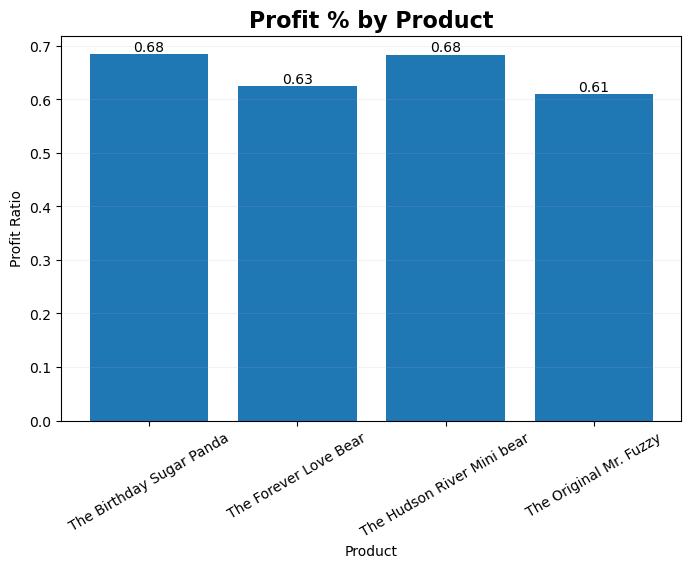

In [58]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    profit_by_product.index,
    profit_by_product['profit_pct']
)

plt.xlabel("Product")
plt.ylabel("Profit Ratio")
plt.title("Profit % by Product",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=30)

# data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )
plt.grid(axis='y', alpha=0.15)
plt.show()


## no of unit sold by product

In [59]:
units_sold_by_product = (
    df_items
    .groupby('product_name')
    .size()
)

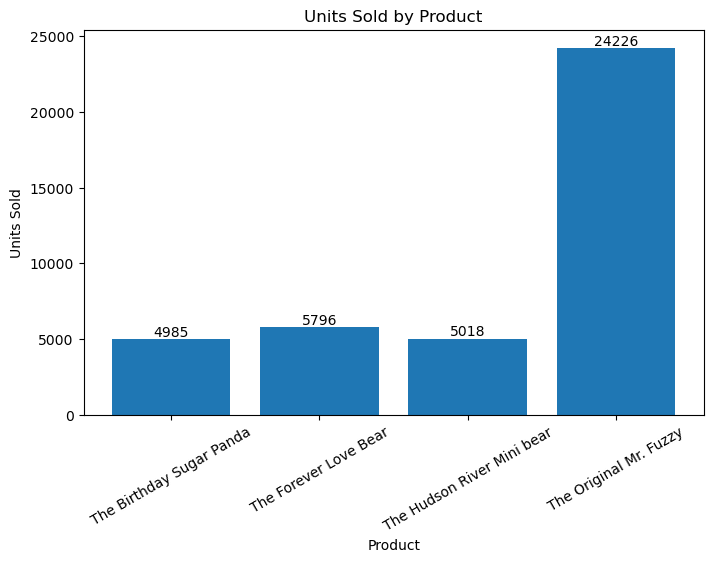

In [60]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    units_sold_by_product.index,
    units_sold_by_product.values
)

plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.title("Units Sold by Product")
plt.xticks(rotation=30)

# 🔹 Data labels (counts)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.show()


## 5A- Product Volume vs Profitability (Bubble)

In [61]:
product_summary = (
    profit_by_product[['profit_pct']]
    .merge(
        units_sold_by_product.rename('units_sold'),
        left_index=True,
        right_index=True
    )
)

product_summary

,profit_pct,units_sold
product_name,,
The Birthday Sugar Panda,0.684932,4985
The Forever Love Bear,0.625104,5796
The Hudson River Mini bear,0.683561,5018
The Original Mr. Fuzzy,0.610122,24226


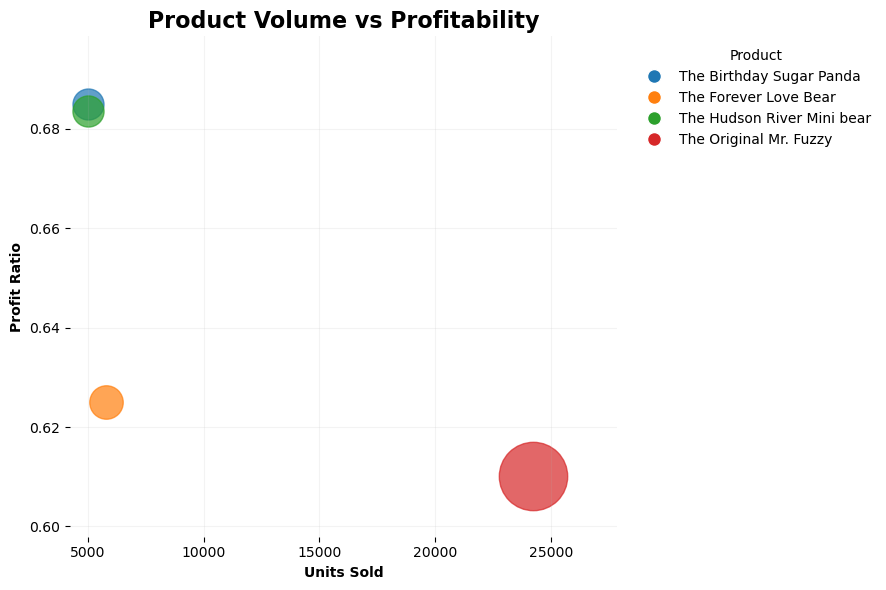

In [62]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(9, 6))

colors = plt.cm.tab10(range(len(product_summary)))

# Scatter plot (NO text labels)
for (product, row), color in zip(product_summary.iterrows(), colors):
    plt.scatter(
        row['units_sold'],
        row['profit_pct'],
        s=row['units_sold'] / 10,
        color=color,
        alpha=0.7
    )

# Axis padding
xmin, xmax = product_summary['units_sold'].min(), product_summary['units_sold'].max()
ymin, ymax = product_summary['profit_pct'].min(), product_summary['profit_pct'].max()

plt.xlim(xmin * 0.85, xmax * 1.15)
plt.ylim(ymin * 0.98, ymax * 1.02)

plt.xlabel("Units Sold",fontweight='semibold')
plt.ylabel("Profit Ratio",fontweight='semibold')
plt.title("Product Volume vs Profitability",
         fontsize = 16,
         fontweight='semibold')

# ✅ Custom legend with equal-sized markers
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=product,
        markerfacecolor=color,
        markersize=10
    )
    for (product, _), color in zip(product_summary.iterrows(), colors)
]

plt.legend(
    handles=legend_elements,
    title="Product",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon= False
)
plt.grid('y', alpha=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.tight_layout()
plt.show()

## Product Portfolio: Scale vs Profitability
- High-volume products drive scale, while newer products maintain strong profit margins.
- Overall product portfolio demonstrates healthy unit economics across all offerings.

“Our product portfolio balances scale and margin effectively. While the flagship product drives volume, newer products maintain strong margins, providing flexibility for pricing, bundling, and future growth strategies.”

## Prepare time column (monthly)

In [63]:
df_items_time = (
    order_items
    .merge(products, on='product_id', how='left')
)

df_items_time['month'] = df_items_time['created_at_x'].dt.to_period('M')

## Monthly units sold by product

In [64]:
monthly_units = (
    df_items_time
    .groupby(['month', 'product_name'])
    .size()
    .reset_index(name='units_sold')
)

monthly_units

,month,product_name,units_sold
0,2012-03,The Original Mr. Fuzzy,60
1,2012-04,The Original Mr. Fuzzy,99
2,2012-05,The Original Mr. Fuzzy,108
3,2012-06,The Original Mr. Fuzzy,140
4,2012-07,The Original Mr. Fuzzy,169
...,...,...,...
89,2015-02,The Original Mr. Fuzzy,1113
90,2015-03,The Birthday Sugar Panda,263
91,2015-03,The Forever Love Bear,223
92,2015-03,The Hudson River Mini bear,343


In [65]:
monthly_revenue = (
    df_items_time
    .groupby(['month', 'product_name'])['price_usd']
    .sum()
    .reset_index(name='revenue')
)

monthly_revenue

,month,product_name,revenue
0,2012-03,The Original Mr. Fuzzy,2999.40
1,2012-04,The Original Mr. Fuzzy,4949.01
2,2012-05,The Original Mr. Fuzzy,5398.92
3,2012-06,The Original Mr. Fuzzy,6998.60
4,2012-07,The Original Mr. Fuzzy,8448.31
...,...,...,...
89,2015-02,The Original Mr. Fuzzy,55638.87
90,2015-03,The Birthday Sugar Panda,12095.37
91,2015-03,The Forever Love Bear,13377.77
92,2015-03,The Hudson River Mini bear,10286.57


In [66]:
# product wise monthly sales
product_wise_monthly_sales= monthly_revenue.pivot(
    index='month',
    columns='product_name',
    values='revenue').fillna(0).reset_index()
product_wise_monthly_sales

product_name,month,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
0,2012-03,0.00,0.00,0.00,2999.40
1,2012-04,0.00,0.00,0.00,4949.01
2,2012-05,0.00,0.00,0.00,5398.92
3,2012-06,0.00,0.00,0.00,6998.60
4,2012-07,0.00,0.00,0.00,8448.31
5,2012-08,0.00,0.00,0.00,11397.72
6,2012-09,0.00,0.00,0.00,14347.13
7,2012-10,0.00,0.00,0.00,18546.29
8,2012-11,0.00,0.00,0.00,30893.82
9,2012-12,0.00,0.00,0.00,25294.94


In [67]:
monthly_units.groupby('product_name')['month'].nunique()

product_name
The Birthday Sugar Panda      16
The Forever Love Bear         27
The Hudson River Mini bear    14
The Original Mr. Fuzzy        37
Name: month, dtype: int64

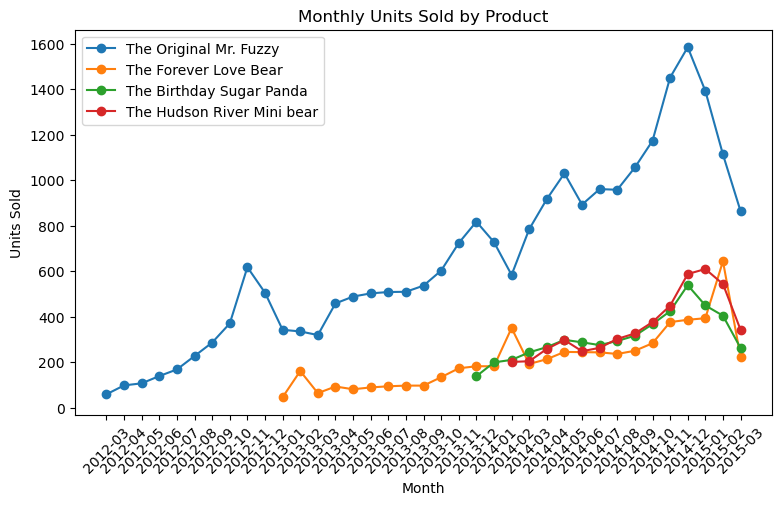

In [68]:
plt.figure(figsize=(9, 5))

for product in monthly_units['product_name'].unique():
    subset = monthly_units[monthly_units['product_name'] == product]
    plt.plot(
        subset['month'].astype(str),
        subset['units_sold'],
        marker='o',
        label=product
    )

plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.title("Monthly Units Sold by Product")
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [69]:
df_items_time['quarter'] = df_items_time['month'].dt.to_timestamp().dt.to_period('Q')

In [70]:
quarterly_units = (
    df_items_time
    .groupby(['quarter', 'product_name'])
    .size()
    .reset_index(name='units_sold')
)

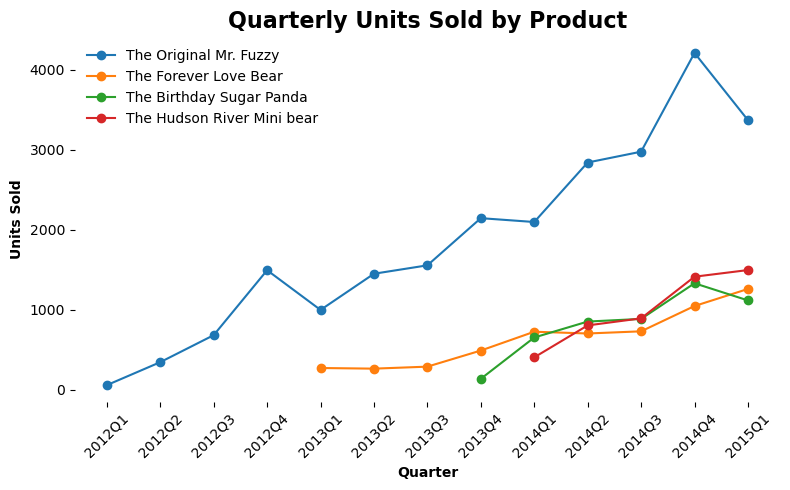

In [71]:
plt.figure(figsize=(8, 5))

for product in quarterly_units['product_name'].unique():
    subset = quarterly_units[quarterly_units['product_name'] == product]
    plt.plot(
        subset['quarter'].astype(str),
        subset['units_sold'],
        marker='o',
        label=product
    )

plt.xlabel("Quarter",fontweight= 'semibold')
plt.ylabel("Units Sold",fontweight= 'semibold')
plt.title("Quarterly Units Sold by Product",
         fontsize = 16,
         fontweight= 'semibold')
plt.xticks(rotation=45)
plt.legend(frameon=False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()

plt.show()

## 4- Quarterly Revenue by Product (Stacked Bar)

## a item-level revenue with product names

In [72]:
##  Merge order_items with orders & products
order_items_rev = (
    order_items
    .merge(orders[['order_id', 'created_at']], on='order_id', how='left')
    .merge(products, on='product_id', how='left')
)

# Create quarter
order_items_rev['quarter'] = (
    order_items_rev['created_at_x']
    .dt.to_period('Q')
    .astype(str)
)

## b Aggregate revenue by quarter & product

In [73]:
quarterly_product_revenue = (
    order_items_rev
    .groupby(['quarter', 'product_name'])['price_usd']
    .sum()
    .reset_index()
)

## c Pivot for stacked bar chart

In [74]:
revenue_pivot = quarterly_product_revenue.pivot(
    index='quarter',
    columns='product_name',
    values='price_usd'
).fillna(0)
revenue_pivot.reset_index()

product_name,quarter,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
0,2012Q1,0.00,0.00,0.00,2999.40
1,2012Q2,0.00,0.00,0.00,17346.53
2,2012Q3,0.00,0.00,0.00,34193.16
3,2012Q4,0.00,0.00,0.00,74735.05
4,2013Q1,0.00,16437.26,0.00,49940.01
5,2013Q2,0.00,15957.34,0.00,72535.49
6,2013Q3,0.00,17457.09,0.00,77784.44
7,2013Q4,6392.61,29515.08,0.00,107228.55
8,2014Q1,30123.45,43612.73,12205.93,104829.03
9,2014Q2,39275.46,42292.95,24171.94,141971.60


## d Plot stacked bar chart

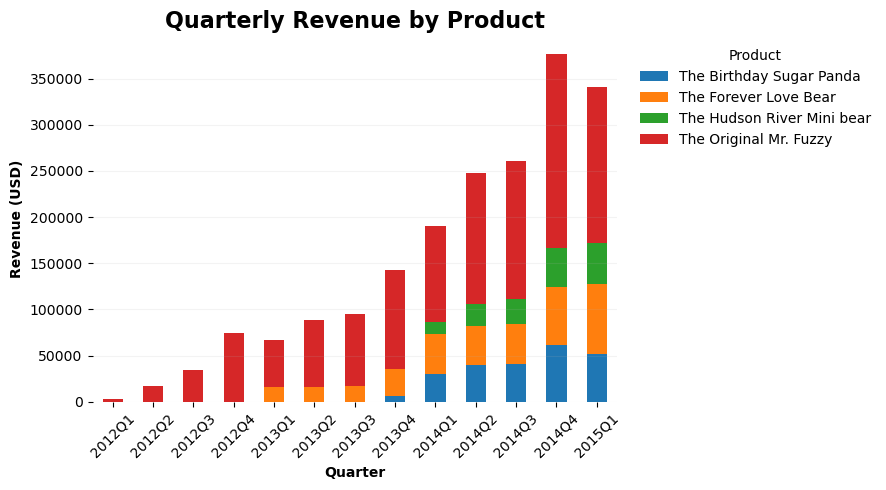

In [75]:
revenue_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.xlabel("Quarter",fontweight='semibold')
plt.ylabel("Revenue (USD)",fontweight='semibold')
plt.title("Quarterly Revenue by Product",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=45)
plt.legend(
    title="Product",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon = False
)
plt.grid(axis='y', alpha=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.tight_layout()
plt.show()



# profit margin of products over time

In [76]:
item_products=order_items.merge(products[['product_id','product_name']], on='product_id', how='left')
item_products['year']=item_products['created_at'].dt.year
item_products['month']=item_products['created_at'].dt.month
monthly_sales_by_products=(
    item_products
    .groupby(['year','month','product_name'])[['cogs_usd','price_usd']].agg(['sum'])
).reset_index()
monthly_sales_by_products['profit_margin'] = monthly_sales_by_products['price_usd'] - monthly_sales_by_products['cogs_usd']
monthly_sales_by_products=monthly_sales_by_products.pivot(index=['year','month'], columns='product_name', values='profit_margin').fillna(0).reset_index()
monthly_sales_by_products

product_name,year,month,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
0,2012,3,0.0,0.0,0.0,1830.0
1,2012,4,0.0,0.0,0.0,3019.5
2,2012,5,0.0,0.0,0.0,3294.0
3,2012,6,0.0,0.0,0.0,4270.0
4,2012,7,0.0,0.0,0.0,5154.5
5,2012,8,0.0,0.0,0.0,6954.0
6,2012,9,0.0,0.0,0.0,8753.5
7,2012,10,0.0,0.0,0.0,11315.5
8,2012,11,0.0,0.0,0.0,18849.0
9,2012,12,0.0,0.0,0.0,15433.0


# Tracking Growth: Monthly Product Sessions & Clickthrough Trends

In [77]:
website_pageviews = website_pageviews.sort_values(['website_session_id', 'created_at'])
website_pageviews['year']=website_pageviews['created_at'].dt.year
website_pageviews['month']=website_pageviews['created_at'].dt.month
products_sessions=website_pageviews[website_pageviews['pageview_url']=='/products'].copy()
monthly_product_sessions=(
    products_sessions
    .groupby(['year','month'])['website_session_id']
    .nunique()
    .reset_index(name='product_sessions')
)
monthly_product_sessions.head()


,year,month,product_sessions
0,2012,3,743
1,2012,4,1447
2,2012,5,1584
3,2012,6,1752
4,2012,7,2018


In [78]:
last_page_per_session = (
   website_pageviews
    .groupby('website_session_id')
    .tail(1)[['website_session_id', 'pageview_url']]
    .rename(columns={'pageview_url': 'last_page'})
)
last_page_per_session_filtered=last_page_per_session[~last_page_per_session['last_page'].isin(['/home','/lander-1','/lander-2','/products', '/lander-4', '/lander-5','/lander-3'])]
filtered = website_pageviews[website_pageviews['website_session_id'].isin(last_page_per_session_filtered['website_session_id'])]
clickthrough_count=filtered.groupby(['year','month'])['website_session_id'].nunique().reset_index(name='clickthrough_sessions')
clickthrough_count.head()

,year,month,clickthrough_sessions
0,2012,3,530
1,2012,4,1030
2,2012,5,1136
3,2012,6,1248
4,2012,7,1439


In [79]:
website_pageviews.pageview_url.unique()

array(['/home', '/products', '/the-original-mr-fuzzy', '/cart',
       '/shipping', '/billing', '/thank-you-for-your-order', '/lander-1',
       '/billing-2', '/the-forever-love-bear', '/lander-2', '/lander-3',
       '/the-birthday-sugar-panda', '/lander-4', '/lander-5',
       '/the-hudson-river-mini-bear'], dtype=object)

In [80]:
df=website_pageviews.copy()
df['page_order']=df.groupby('website_session_id').cumcount()
product_order=(
    df[df['pageview_url']=='/products']
    .groupby('website_session_id')['page_order']
    .min()
    .reset_index(name='product_order')
)
post_product=df.merge(product_order, on='website_session_id', how='inner')
forward_pages = [
    '/the-original-mr-fuzzy',
    '/the-forever-love-bear',
    '/the-birthday-sugar-panda',
    '/the-hudson-river-mini-bear',
    '/cart',
    '/shipping',
    '/billing',
    '/billing-2',
    '/thank-you-for-your-order'
]

post_product_sessions=post_product[(post_product['page_order'] > post_product['product_order'])&
    (post_product['pageview_url'].isin(forward_pages))
]
clickthrough_sessions=post_product_sessions.sort_values(['website_session_id','page_order']).drop_duplicates(subset='website_session_id')
# monthly aggrigation
clickthrough_count=clickthrough_sessions.groupby(['year','month'])['website_session_id'].nunique().reset_index(name='clickthrough_sessions')
clickthrough_count.head()
agg= monthly_product_sessions.merge(clickthrough_count, on=['year','month'], how='left')
agg

,year,month,product_sessions,clickthrough_sessions
0,2012,3,743,530
1,2012,4,1447,1029
2,2012,5,1584,1135
3,2012,6,1752,1247
4,2012,7,2018,1438
5,2012,8,3012,2198
6,2012,9,3126,2258
7,2012,10,4030,2948
8,2012,11,6743,4849
9,2012,12,5013,3620


In [81]:
clickthrough_count.head()

,year,month,clickthrough_sessions
0,2012,3,530
1,2012,4,1029
2,2012,5,1135
3,2012,6,1247
4,2012,7,1438


### refund amount

## 1- Product Revenue Contribution Over Time
- The flagship product remains the primary revenue driver while newer products progressively contribute to overall revenue.
- Revenue diversification improves over time, reducing reliance on a single product.

“Our flagship product continues to anchor revenue growth, benefiting from early market entry. Over time, newly introduced products have begun contributing meaningfully, improving portfolio diversification and reducing single-product dependency.”

In [82]:
website_pageviews = website_pageviews.sort_values(['website_session_id','website_pageview_id'])

In [83]:
website_pageviews.head(100)

,website_pageview_id,created_at,website_session_id,pageview_url,year,month
0,1,2012-03-19 08:04:16,1,/home,2012,3
1,2,2012-03-19 08:16:49,2,/home,2012,3
2,3,2012-03-19 08:26:55,3,/home,2012,3
3,4,2012-03-19 08:37:33,4,/home,2012,3
4,5,2012-03-19 09:00:55,5,/home,2012,3
...,...,...,...,...,...,...
95,96,2012-03-19 14:12:09,54,/home,2012,3
96,97,2012-03-19 14:14:07,54,/products,2012,3
98,99,2012-03-19 14:18:16,54,/the-original-mr-fuzzy,2012,3
97,98,2012-03-19 14:15:08,55,/home,2012,3


## Sessions Growth Over Time (Quarterly)

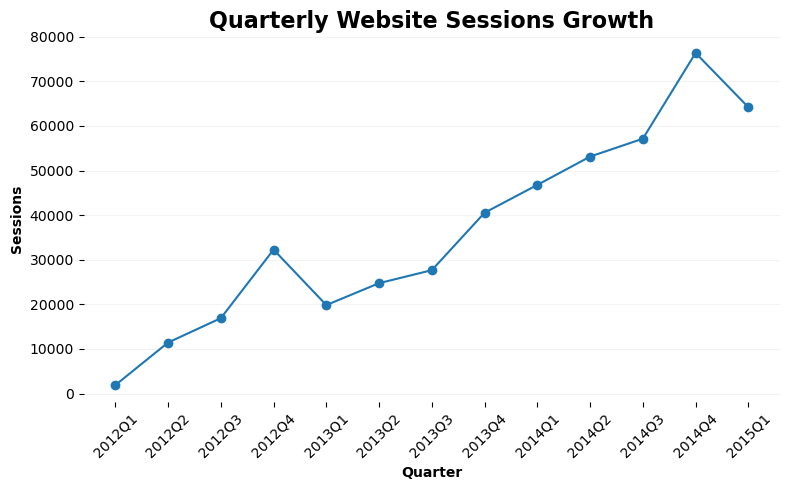

In [84]:
# Create quarter column
website_sessions['quarter'] = (
    website_sessions['created_at']
    .dt.to_period('Q')
    .astype(str)
)

# Aggregate sessions per quarter
quarterly_sessions = (
    website_sessions
    .groupby('quarter')['website_session_id']
    .nunique()
    .reset_index(name='sessions')
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(
    quarterly_sessions['quarter'],
    quarterly_sessions['sessions'],
    marker='o'
)

plt.xlabel("Quarter",fontweight='semibold')
plt.ylabel("Sessions",fontweight='semibold')
plt.title("Quarterly Website Sessions Growth",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.15)

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()
plt.show()

In [85]:
orders['quarter']=orders['created_at'].dt.to_period('Q').astype(str)
quarterly_orders=orders.groupby('quarter')['order_id'].nunique().reset_index()
quarterly_orders

,quarter,order_id
0,2012Q1,60
1,2012Q2,347
2,2012Q3,684
3,2012Q4,1495
4,2013Q1,1273
5,2013Q2,1717
6,2013Q3,1841
7,2013Q4,2616
8,2014Q1,3069
9,2014Q2,3848


In [86]:
quarterly_sessions

,quarter,sessions
0,2012Q1,1879
1,2012Q2,11433
2,2012Q3,16892
3,2012Q4,32266
4,2013Q1,19833
5,2013Q2,24745
6,2013Q3,27663
7,2013Q4,40540
8,2014Q1,46779
9,2014Q2,53129


In [87]:
# quarterly revenue per order
revenue_per_order = orders.groupby('quarter')['price_usd'].mean().reset_index()
revenue_per_order

,quarter,price_usd
0,2012Q1,49.990000
1,2012Q2,49.990000
2,2012Q3,49.990000
3,2012Q4,49.990000
4,2013Q1,52.142396
5,2013Q2,51.539214
6,2013Q3,51.733585
7,2013Q4,54.715688
8,2014Q1,62.160684
9,2014Q2,64.374207


# Monthly sessions conversion from /products page to orders

In [88]:
# Monthly sessions conversion from /products page to orders
products_pageviews = website_pageviews.loc[
    website_pageviews['pageview_url'] == '/products'
].copy()
products_pageviews.loc[:,'month'] = products_pageviews['created_at'].dt.month
products_pageviews.loc[:,'year'] = products_pageviews['created_at'].dt.year
monthly_product_views = (
    products_pageviews
    .groupby(['year', 'month'])['website_session_id']
    .nunique()
    .reset_index(name='product_pageviews')
)   
orders['month']=orders['created_at'].dt.month
monthly_orders= orders.groupby(['year', 'month'])['website_session_id'].nunique().reset_index(name='orders')
conversion = monthly_orders.merge(
    monthly_product_views, on=['year', 'month']
)
conversion['conversion_rate']=(
    conversion['orders'] / conversion['product_pageviews'] * 100
)
conversion

,year,month,orders,product_pageviews,conversion_rate
0,2012,3,60,743,8.075370
1,2012,4,99,1447,6.841742
2,2012,5,108,1584,6.818182
3,2012,6,140,1752,7.990868
4,2012,7,169,2018,8.374628
5,2012,8,228,3012,7.569721
6,2012,9,287,3126,9.181062
7,2012,10,371,4030,9.205955
8,2012,11,618,6743,9.165060
9,2012,12,506,5013,10.093756


## Traffic Growth & Market Demand
- Website sessions show strong quarter-over-quarter growth, indicating rising market interest.
- Traffic acceleration through 2013–2014 reflects improving acquisition efficiency and brand visibility.

“We see consistent growth in website sessions over time, particularly accelerating through 2013 and 2014. This confirms sustained demand and growing awareness of our products, giving us a strong top-of-funnel base to monetize.”

“Quarterly fluctuations are expected, but the long-term trend remains strongly positive.”

## 2- Traffic Mix by Source (Demand Quality & Risk)

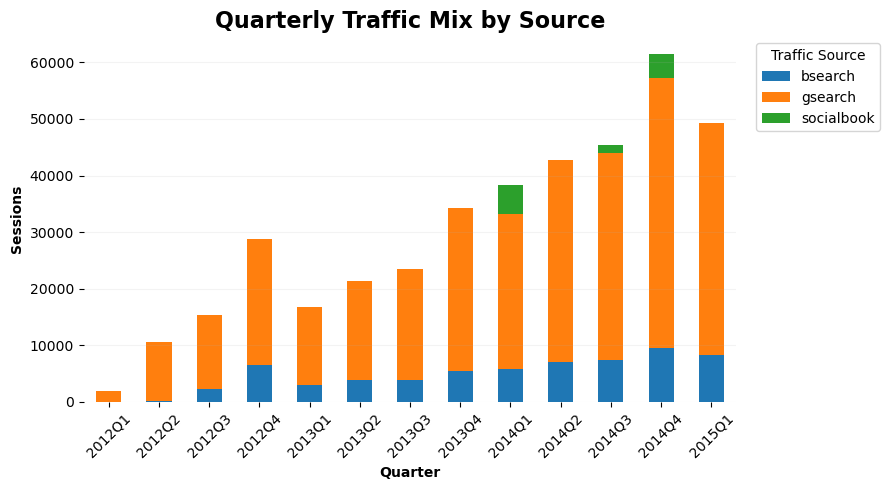

In [89]:
# Aggregate sessions by quarter & source
traffic_mix = (
    website_sessions
    .groupby(['quarter', 'utm_source'])['website_session_id']
    .nunique()
    .reset_index(name='sessions')
)

# Pivot for stacked bar chart
traffic_pivot = traffic_mix.pivot(
    index='quarter',
    columns='utm_source',
    values='sessions'
).fillna(0)

# Plot
traffic_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.xlabel("Quarter",fontweight='semibold')
plt.ylabel("Sessions",fontweight='semibold')
plt.title("Quarterly Traffic Mix by Source",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=45)
plt.legend(title="Traffic Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.grid(axis='y', alpha=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()

plt.show()

In [90]:
traffic_pivot.reset_index()

utm_source,quarter,bsearch,gsearch,socialbook
0,2012Q1,2.0,1860.0,0.0
1,2012Q2,61.0,10562.0,0.0
2,2012Q3,2188.0,13179.0,0.0
3,2012Q4,6578.0,22287.0,0.0
4,2013Q1,2926.0,13764.0,0.0
5,2013Q2,3766.0,17598.0,0.0
6,2013Q3,3932.0,19465.0,0.0
7,2013Q4,5435.0,28845.0,0.0
8,2014Q1,5720.0,27429.0,5095.0
9,2014Q2,7110.0,35578.0,0.0


## Traffic Mix & Acquisition Quality

- Traffic growth is primarily driven by search, supported by increasing direct and unattributed visits.  
- The acquisition mix remains stable over time, indicating manageable channel dependency and growing brand recall.

“Our traffic acquisition is led by search channels, giving us predictable and controllable growth. Importantly, we also see a consistent rise in direct and unattributed traffic, which typically reflects improving brand awareness and repeat visitor behavior. This helps reduce long-term dependency on paid channels.”

# Find the FIRST time each session hits each funnel stage

In [91]:
website_pageviews.pageview_url.unique()

array(['/home', '/products', '/the-original-mr-fuzzy', '/cart',
       '/shipping', '/billing', '/thank-you-for-your-order', '/lander-1',
       '/billing-2', '/the-forever-love-bear', '/lander-2', '/lander-3',
       '/the-birthday-sugar-panda', '/lander-4', '/lander-5',
       '/the-hudson-river-mini-bear'], dtype=object)

## Define funnel groups

In [92]:
landing_pages = [
                '/home','/lander-1','/lander-2',
                '/lander-3','/lander-4', '/lander-5'
                ]

product_pages = [
                '/products','/the-original-mr-fuzzy','/the-forever-love-bear',
                '/the-birthday-sugar-panda','/the-hudson-river-mini-bear'
                ]

billing_pages = [
                '/billing','/billing-2']

cart_page=  '/cart'

shipping_page = '/shipping'

thankyou_pages = '/thank-you-for-your-order'

## Keep only funnel-related pageviews

In [93]:
funnel_df= website_pageviews[
        website_pageviews['pageview_url'].isin(
            landing_pages
            + product_pages
            + [cart_page, shipping_page, thankyou_pages]
            + billing_pages
        )
    ].copy()

## First pageview ID per session per step

In [94]:
session_steps= (
    funnel_df
    .groupby(['website_session_id','pageview_url'])['website_pageview_id']
    .min()
    .reset_index()
)

In [95]:
session_steps

,website_session_id,pageview_url,website_pageview_id
0,1,/home,1
1,2,/home,2
2,3,/home,3
3,4,/home,4
4,5,/home,5
...,...,...,...
1188119,472869,/lander-3,1188116
1188120,472870,/lander-5,1188118
1188121,472870,/products,1188119
1188122,472870,/the-original-mr-fuzzy,1188121


## Pivot to one row per session

In [96]:
session_steps= session_steps.pivot(
    index = 'website_session_id',
    columns='pageview_url',
    values = 'website_pageview_id'
)

In [97]:
session_steps

pageview_url,/billing,/billing-2,/cart,/home,/lander-1,/lander-2,/lander-3,/lander-4,/lander-5,/products,/shipping,/thank-you-for-your-order,/the-birthday-sugar-panda,/the-forever-love-bear,/the-hudson-river-mini-bear,/the-original-mr-fuzzy
website_session_id,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472867,NaN,NaN,NaN,1188111.0,NaN,NaN,NaN,NaN,NaN,1188113.0,NaN,NaN,NaN,NaN,NaN,NaN
472868,NaN,NaN,NaN,NaN,NaN,NaN,1188114.0,NaN,NaN,1188117.0,NaN,NaN,NaN,NaN,NaN,1188124.0
472869,NaN,NaN,NaN,NaN,NaN,NaN,1188116.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Landing → Product → Cart → Shipping → Billing → Thank You

In [98]:
funnel_steps = session_steps.copy()

In [99]:
funnel_steps['landing']= funnel_steps[landing_pages].min(axis = 1)
funnel_steps['product']= funnel_steps[product_pages].min(axis =1)
funnel_steps['cart']= funnel_steps[cart_page]
funnel_steps['shipping']= funnel_steps[shipping_page]
funnel_steps['billing']=funnel_steps[billing_pages].min(axis=1)
funnel_steps['thankyou'] = funnel_steps[thankyou_pages]

## Enforce ORDER

In [100]:
funnel_steps['product_ok'] = funnel_steps['product']>funnel_steps['landing']

funnel_steps['cart_ok']= funnel_steps['cart']>funnel_steps['product']

funnel_steps['shipping_ok']= funnel_steps['shipping']>funnel_steps['cart']

funnel_steps['billing_ok']= funnel_steps['billing']>funnel_steps['shipping']

funnel_steps['thankyou_ok']= funnel_steps['thankyou']>funnel_steps['billing']

## 3A Website Conversion Funnel (Counts)

In [101]:
sessions_landing = funnel_steps['landing'].notna().sum()
sessions_product = funnel_steps['product_ok'].sum()
sessions_cart = funnel_steps['cart_ok'].sum()
sessions_shipping = funnel_steps['shipping_ok'].sum()
sessions_billing = funnel_steps['billing_ok'].sum()
sessions_thankyou = funnel_steps['thankyou_ok'].sum()

funnel_counts = {
    'Landing': sessions_landing,
    'Product': sessions_product,
    'Cart': sessions_cart,
    'Shipping': sessions_shipping,
    'Billing': sessions_billing,
    'Thank You': sessions_thankyou
}

funnel_counts

{'Landing': np.int64(472871),
 'Product': np.int64(261231),
 'Cart': np.int64(94953),
 'Shipping': np.int64(64484),
 'Billing': np.int64(52058),
 'Thank You': np.int64(32313)}

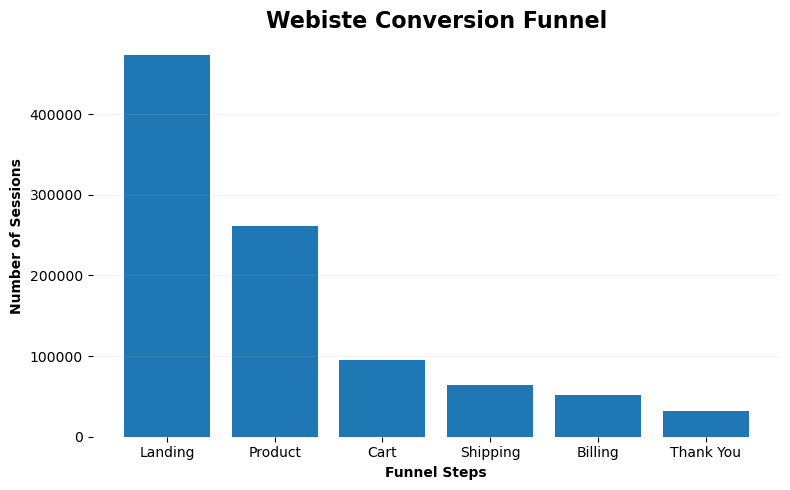

In [102]:
steps = list(funnel_counts.keys())
counts= list(funnel_counts.values())

plt.figure(figsize=(8,5))
plt.bar(steps,counts)
plt.xlabel("Funnel Steps",fontweight='semibold')
plt.ylabel("Number of Sessions",fontweight='semibold')
plt.title("Webiste Conversion Funnel",
         fontsize=16,
         fontweight='semibold')
plt.grid(axis='y', alpha=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()
plt.show()

## Website Conversion Funnel
- Users move through a clearly defined funnel from landing to purchase.
- Drop-offs follow expected e-commerce patterns, indicating a functional conversion engine.

“This funnel shows that users don’t just visit the site — they actively engage with products and move through checkout. The structure is healthy, and the drop-offs we see are typical of e-commerce flows rather than signs of user friction.”

## Conversion rate between steps

In [103]:
conversion_rates = []
for i in range(1,len(counts)):
    rate = counts[i]/counts[i-1]
    conversion_rates.append(rate)
    print(f"{steps[i-1]} → {steps[i]} : {rate*100:.2f}%")

Landing → Product : 55.24%
Product → Cart : 36.35%
Cart → Shipping : 67.91%
Shipping → Billing : 80.73%
Billing → Thank You : 62.07%


In [104]:
conversion_labels = []
conversion_values = []

for i in range(1, len(counts)):
    conversion_labels.append(f"{steps[i-1]} → {steps[i]}")
    conversion_values.append(counts[i] / counts[i-1])
conversion_labels, conversion_values, conversion_rates

(['Landing → Product',
  'Product → Cart',
  'Cart → Shipping',
  'Shipping → Billing',
  'Billing → Thank You'],
 [np.float64(0.5524360766466965),
  np.float64(0.3634828944497399),
  np.float64(0.6791149305445853),
  np.float64(0.8073010359158861),
  np.float64(0.6207115140804488)],
 [np.float64(0.5524360766466965),
  np.float64(0.3634828944497399),
  np.float64(0.6791149305445853),
  np.float64(0.8073010359158861),
  np.float64(0.6207115140804488)])

## 3B — Step-wise Conversion Rates

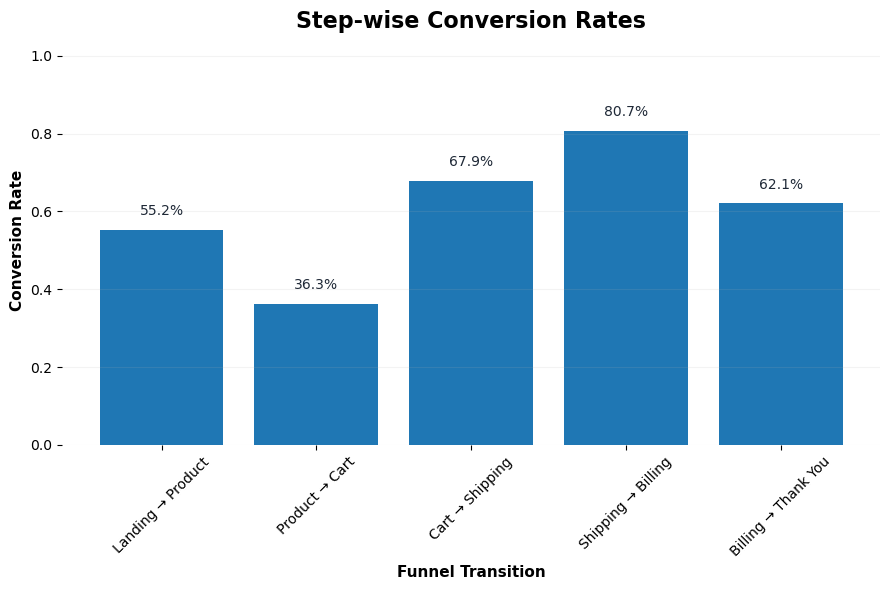

In [105]:
plt.figure(figsize=(9,6))

bars = plt.bar(conversion_labels, conversion_values)

plt.ylabel("Conversion Rate", fontsize=11, fontweight = 'semibold')
plt.xlabel("Funnel Transition", fontsize=11 , fontweight= 'semibold')

plt.title(
    "Step-wise Conversion Rates",
    fontsize=16,
    fontweight='semibold'
)

plt.xticks(rotation=45)
plt.ylim(0, 1.05)  # extra headroom for labels

# ----- DATA LABELS (FIXED) -----
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.03,          # <-- KEY FIX (padding)
        f"{height*100:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color='#1F2937'
    )

# ----- Styling -----
plt.grid(axis='y', alpha=0.15)

ax = plt.gca()
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()

plt.show()

## Funnel Conversion Efficiency
- Mid-funnel represents the primary drop-off point, while checkout stages show strong conversion efficiency.
- High downstream conversion indicates solid checkout experience and purchase intent.

“The most significant drop-off occurs before cart addition, which is typical and represents an optimization opportunity. Importantly, once users reach the cart and checkout stages, conversion rates are strong, indicating trust in pricing, UX, and payment flow.”

### Funnel split by Device Type (Desktop vs Mobile)

## Join pageviews with sessions (to get device)

In [106]:
pv_sessions = website_pageviews.merge(
    website_sessions[['website_session_id', 'device_type']],
    on='website_session_id',
    how='left'
)

In [107]:
pv_sessions['device_type'].value_counts()

device_type
desktop    881940
mobile     306184
Name: count, dtype: int64

## Function to compute funnel counts (REUSABLE)

In [108]:
def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

def compute_funnel_counts(df):
    funnel_df = df[
        df['pageview_url'].isin(
            landing_pages
            + product_pages
            + [cart_page, shipping_page, thankyou_pages]
            + billing_pages
        )
    ].copy()

    session_steps = (
        funnel_df
        .groupby(['website_session_id', 'pageview_url'])['website_pageview_id']
        .min()
        .unstack()
    )

    funnel_steps = session_steps.copy()

    funnel_steps['landing'] = funnel_steps[existing_cols(funnel_steps, landing_pages)].min(axis=1)

    funnel_steps['product'] = funnel_steps[existing_cols(funnel_steps, product_pages)].min(axis=1)
    funnel_steps['cart'] = funnel_steps[cart_page]
    funnel_steps['shipping'] = funnel_steps[shipping_page]
    funnel_steps['billing'] = funnel_steps[existing_cols(funnel_steps, billing_pages)].min(axis=1)
    funnel_steps['thankyou'] = funnel_steps[thankyou_pages]

    return {
        'Landing': funnel_steps['landing'].notna().sum(),
        'Product': (funnel_steps['product'] > funnel_steps['landing']).sum(),
        'Cart': (funnel_steps['cart'] > funnel_steps['product']).sum(),
        'Shipping': (funnel_steps['shipping'] > funnel_steps['cart']).sum(),
        'Billing': (funnel_steps['billing'] > funnel_steps['shipping']).sum(),
        'Thank You': (funnel_steps['thankyou'] > funnel_steps['billing']).sum(),
    }

## 3C — Desktop vs Mobile Funnel

In [109]:
desktop_funnel = compute_funnel_counts(
    pv_sessions[pv_sessions['device_type'] == 'desktop']
)

mobile_funnel = compute_funnel_counts(
    pv_sessions[pv_sessions['device_type'] == 'mobile']
)

print(desktop_funnel, mobile_funnel)

{'Landing': np.int64(327027), 'Product': np.int64(192325), 'Cart': np.int64(75155), 'Shipping': np.int64(52692), 'Billing': np.int64(43722), 'Thank You': np.int64(27805)} {'Landing': np.int64(145844), 'Product': np.int64(68906), 'Cart': np.int64(19798), 'Shipping': np.int64(11792), 'Billing': np.int64(8336), 'Thank You': np.int64(4508)}


## Prepare data for plotting

In [110]:
desktop_steps = list(desktop_funnel.keys())
desktop_counts = list(desktop_funnel.values())

mobile_steps = list(mobile_funnel.keys())
mobile_counts = list(mobile_funnel.values())

In [111]:
mobile_counts

[np.int64(145844),
 np.int64(68906),
 np.int64(19798),
 np.int64(11792),
 np.int64(8336),
 np.int64(4508)]

In [112]:
desktop_counts

[np.int64(327027),
 np.int64(192325),
 np.int64(75155),
 np.int64(52692),
 np.int64(43722),
 np.int64(27805)]

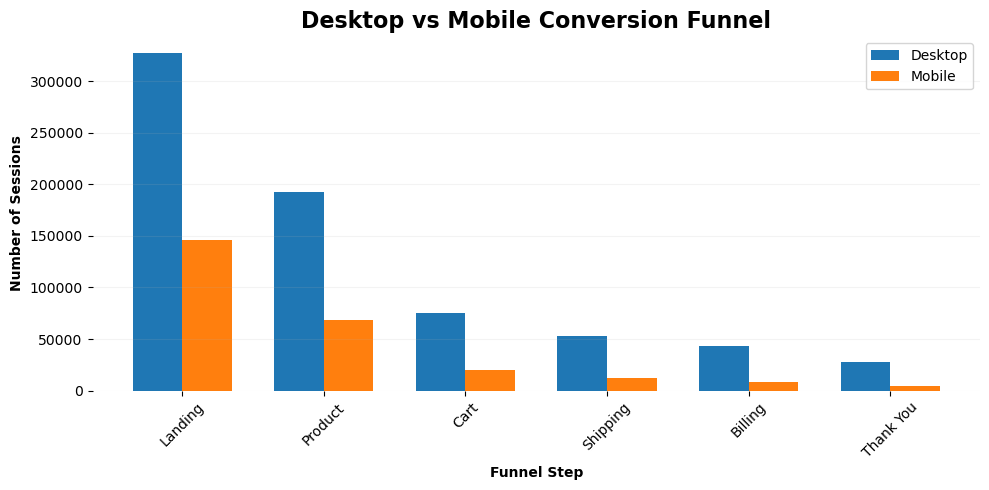

In [113]:
x = np.arange(len(desktop_steps))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(x - width/2, desktop_counts, width, label='Desktop')
plt.bar(x + width/2, mobile_counts, width, label='Mobile')

plt.xticks(x, desktop_steps, rotation=45)
plt.xlabel("Funnel Step",fontweight='semibold')
plt.ylabel("Number of Sessions",fontweight='semibold')
plt.title("Desktop vs Mobile Conversion Funnel",
         fontsize=16,
         fontweight='semibold')
plt.legend()
plt.grid(axis='y',alpha=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()
plt.show()

## Device-Level Conversion Performance
- Desktop users convert significantly better across all funnel stages.
- Mobile traffic presents a clear conversion optimization opportunity.

“Desktop conversion performance is strong and consistent. Mobile traffic is substantial but under-converts, highlighting a clear opportunity for UX and performance optimization. Even modest mobile improvements could unlock meaningful incremental revenue.”

## 4- Revenue & Profit Trend (Quarterly)

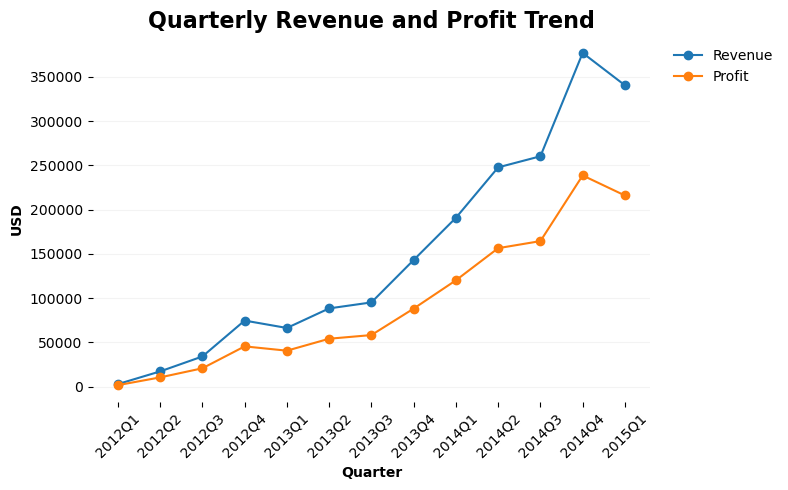

In [114]:
orders['quarter'] = (
    orders['created_at']
    .dt.to_period('Q')
    .astype(str)
)

# Aggregate revenue & cost
quarterly_financials = (
    orders
    .groupby('quarter')
    .agg(
        revenue=('price_usd', 'sum'),
        cost=('cogs_usd', 'sum')
    )
    .reset_index()
)

# Calculate profit
quarterly_financials['profit'] = (
    quarterly_financials['revenue'] - quarterly_financials['cost']
)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    quarterly_financials['quarter'],
    quarterly_financials['revenue'],
    marker='o',
    label='Revenue'
)

plt.plot(
    quarterly_financials['quarter'],
    quarterly_financials['profit'],
    marker='o',
    label='Profit'
)

plt.xlabel("Quarter",fontweight='semibold')
plt.ylabel("USD",fontweight='semibold')
plt.title("Quarterly Revenue and Profit Trend",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=45)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)
plt.grid(axis='y',alpha=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()
plt.show()

In [115]:
quarterly_financials.reset_index(drop=True)[
    ['quarter', 'revenue', 'profit']
]

,quarter,revenue,profit
0,2012Q1,2999.40,1830.0
1,2012Q2,17346.53,10583.5
2,2012Q3,34193.16,20862.0
3,2012Q4,74735.05,45597.5
4,2013Q1,66377.27,40744.5
5,2013Q2,88492.83,54230.5
6,2013Q3,95241.53,58370.5
7,2013Q4,143136.24,88251.0
8,2014Q1,190771.14,120197.0
9,2014Q2,247711.95,156481.5


## Revenue Growth with Scalable Profitability
- Revenue has scaled significantly over time, reflecting effective monetization of growing traffic.
- Profit has increased alongside revenue, indicating stable margins and disciplined cost management.

“As traffic and conversion improved, revenue scaled consistently over time. Importantly, profit has grown in line with revenue, showing that our cost structure scales efficiently and unit economics remain healthy as the business grows.”

## 6 Refunds & Revenue Quality
- 1️⃣ Refund Rate Over Time (Quarterly)
- 2️⃣ Refund Rate by Product

In [116]:
# Merge refunds with order_items and orders
refunds_enriched = (
    order_item_refunds
    .merge(order_items[['order_item_id', 'price_usd']], on='order_item_id', how='left')
    .merge(orders[['order_id', 'created_at', 'price_usd']], on='order_id', how='left', suffixes=('_item', '_order'))
)

In [117]:
refunds_enriched.columns

Index(['order_item_refund_id', 'created_at_item', 'order_item_id', 'order_id',
       'refund_amount_usd', 'price_usd_item', 'created_at_order',
       'price_usd_order'],
      dtype='object')

### a 1️⃣ Create quarter (refund-based timeline)

In [118]:
# Create quarter
refunds_enriched['quarter'] = (
    refunds_enriched['created_at_item']
    .dt.to_period('Q')
    .astype(str)
)

## b 2️⃣ Quarterly refunded amount

In [119]:
quarterly_refunds = (
    refunds_enriched
    .groupby('quarter')['refund_amount_usd']
    .sum()
    .reset_index()
)

## 3️⃣ Quarterly revenue (order-based timeline — correct)

In [120]:
quarterly_revenue = (
    orders
    .groupby(orders['created_at'].dt.to_period('Q').astype(str))['price_usd']
    .sum()
    .reset_index(name='revenue')
)

In [121]:
quarterly_revenue.columns

Index(['created_at', 'revenue'], dtype='object')

In [122]:
quarterly_revenue = quarterly_revenue.rename(
    columns={'created_at': 'quarter'}
)

## 4️⃣ Merge + refund rate

In [123]:
refund_rate_q = quarterly_revenue.merge(quarterly_refunds, on='quarter', how='left').fillna(0)
refund_rate_q['refund_rate_pct'] = refund_rate_q['refund_amount_usd'] / refund_rate_q['revenue'] * 100

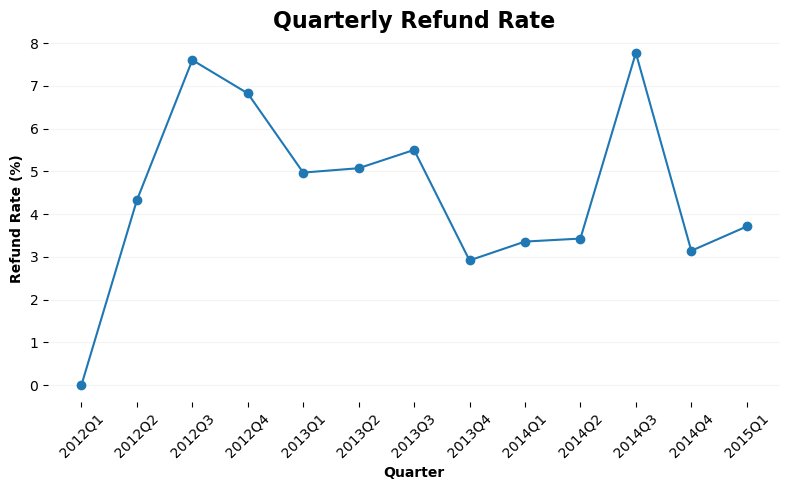

In [124]:
plt.figure(figsize=(8, 5))
plt.plot(
    refund_rate_q['quarter'],
    refund_rate_q['refund_rate_pct'],
    marker='o'
)

plt.xlabel("Quarter",fontweight='semibold')
plt.ylabel("Refund Rate (%)",fontweight='semibold')
plt.title("Quarterly Refund Rate",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=45)
plt.grid(axis= 'y', alpha=0.15)


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()
plt.show()

## Revenue Quality & Refund Stability
- Refund rates remain within a controlled range with no sustained upward trend.
- Short-term spikes normalize quickly, indicating isolated events rather than systemic issues.

“Refund rates fluctuate quarter to quarter, which is expected in a growing e-commerce business. Importantly, we don’t see a persistent upward trend. Periodic spikes normalize quickly, suggesting refunds are driven by isolated events rather than ongoing product or fulfillment issues.”

## 6b  Refund Rate by Product

### Refund amount by product

In [125]:
refunds_by_product = (
    order_item_refunds
    .merge(
        order_items[['order_item_id', 'product_id', 'price_usd']],
        on='order_item_id',
        how='left'
    )
    .merge(
        products[['product_id', 'product_name']],
        on='product_id',
        how='left'
    )
)

product_refunds = (
    refunds_by_product
    .groupby('product_name')['refund_amount_usd']
    .sum()
    .reset_index()
)


### Revenue by product

In [126]:
product_revenue = (
    order_items
    .merge(products[['product_id', 'product_name']], on='product_id', how='left')
    .groupby('product_name')['price_usd']
    .sum()
    .reset_index(name='revenue')
)

### Combine & calculate refund rate

In [127]:
refund_product = (
    product_revenue
    .merge(product_refunds, on='product_name', how='left')
    .fillna(0)
)

refund_product['refund_rate_pct'] = (
    refund_product['refund_amount_usd'] / refund_product['revenue'] * 100
)
refund_product['refund_rate']=(
    refund_product['refund_amount_usd'] / refund_product['revenue']
).round(4)
refund_product


,product_name,revenue,refund_amount_usd,refund_rate_pct,refund_rate
0,The Birthday Sugar Panda,229260.15,13842.99,6.038114,0.0604
1,The Forever Love Bear,347702.04,7738.71,2.225673,0.0223
2,The Hudson River Mini bear,150489.82,1919.36,1.275409,0.0128
3,The Original Mr. Fuzzy,1211057.74,61837.63,5.106084,0.0511


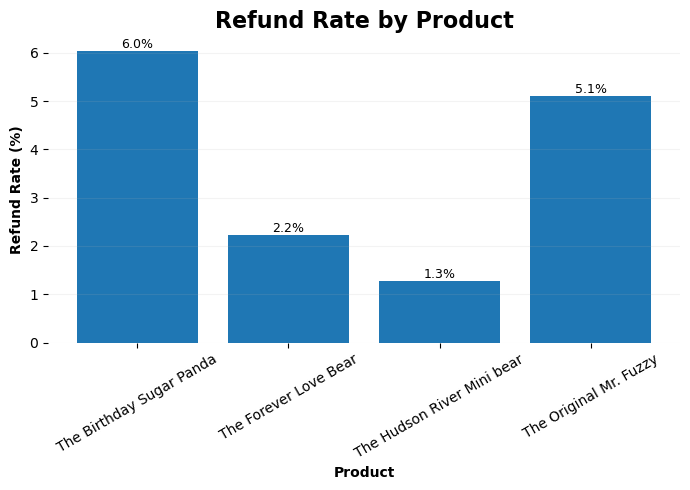

In [128]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    refund_product['product_name'],
    refund_product['refund_rate_pct']
)

plt.xlabel("Product",fontweight='semibold')
plt.ylabel("Refund Rate (%)",fontweight='semibold')
plt.grid(axis='y', alpha=0.15)
plt.title("Refund Rate by Product",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=30)

# Optional data labels (keep subtle)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()
plt.show()

## Product-Level Refund Performance
- Refund rates are controlled and consistent across the product portfolio.
- The flagship product does not exhibit elevated refund risk compared to newer offerings.

“Refund behavior is consistent across products, and importantly the flagship product does not drive disproportionate returns. Newer products show equal or better refund performance, reinforcing overall product quality.”

## 7 Customer Behavior (New vs Repeat Users)

### 7A Quarterly New vs Repeat Sessions

In [129]:
# Classify session type
website_sessions['session_type'] = website_sessions['is_repeat_session'].map({
    0: 'New',
    1: 'Repeat'
})

# Aggregate sessions
quarterly_sessions_type = (
    website_sessions
    .groupby(['quarter', 'session_type'])['website_session_id']
    .nunique()
    .reset_index(name='sessions')
)

# Pivot for plotting
sessions_pivot = quarterly_sessions_type.pivot(
    index='quarter',
    columns='session_type',
    values='sessions'
).fillna(0)

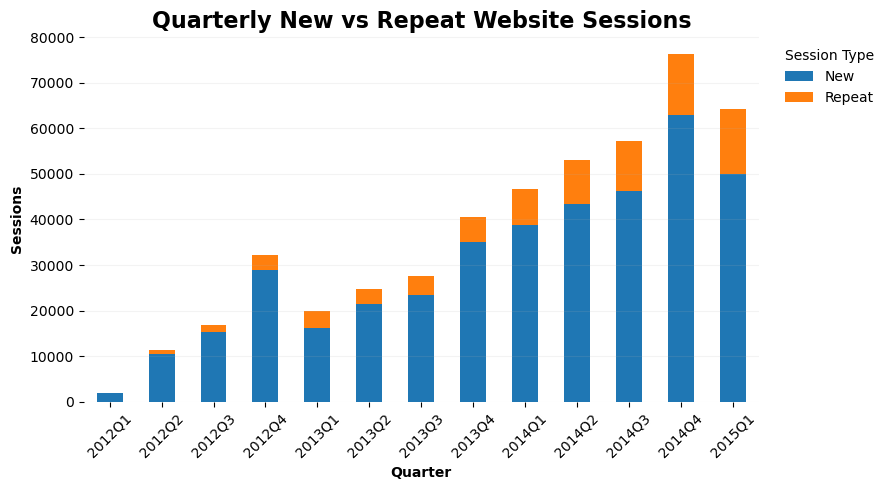

In [130]:
sessions_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.xlabel("Quarter",fontweight='semibold')
plt.ylabel("Sessions",fontweight='semibold')
plt.grid(axis='y', alpha=0.15)
plt.title("Quarterly New vs Repeat Website Sessions",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=45)
plt.legend(title="Session Type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon = False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.tight_layout()
plt.show()

### Customer Engagement: New vs Repeat Sessions
- Repeat sessions increase steadily over time, indicating growing brand engagement.
- New customer acquisition continues to scale alongside repeat usage.

“As we scaled acquisition, we also saw a steady increase in repeat sessions. This suggests improving brand recognition and early signs of customer retention, rather than one-time transactional traffic.”


In [131]:
sessions_pivot.reset_index()

session_type,quarter,New,Repeat
0,2012Q1,1871,8
1,2012Q2,10528,905
2,2012Q3,15249,1643
3,2012Q4,28895,3371
4,2013Q1,16269,3564
5,2013Q2,21429,3316
6,2013Q3,23509,4154
7,2013Q4,35075,5465
8,2014Q1,38704,8075
9,2014Q2,43471,9658


## Repeat Contribution to Orders

### Orders by Session Type

In [132]:
# Merge orders with session info
orders_sessions = orders.merge(
    website_sessions[['website_session_id', 'is_repeat_session']],
    on='website_session_id',
    how='left'
)

orders_sessions['customer_type'] = orders_sessions['is_repeat_session'].map({
    0: 'New Customer',
    1: 'Repeat Customer'
})

# Quarterly orders
orders_sessions['quarter'] = (
    orders_sessions['created_at']
    .dt.to_period('Q')
    .astype(str)
)

quarterly_orders_type = (
    orders_sessions
    .groupby(['quarter', 'customer_type'])['order_id']
    .nunique()
    .reset_index(name='orders')
)

orders_pivot = quarterly_orders_type.pivot(
    index='quarter',
    columns='customer_type',
    values='orders'
).fillna(0)

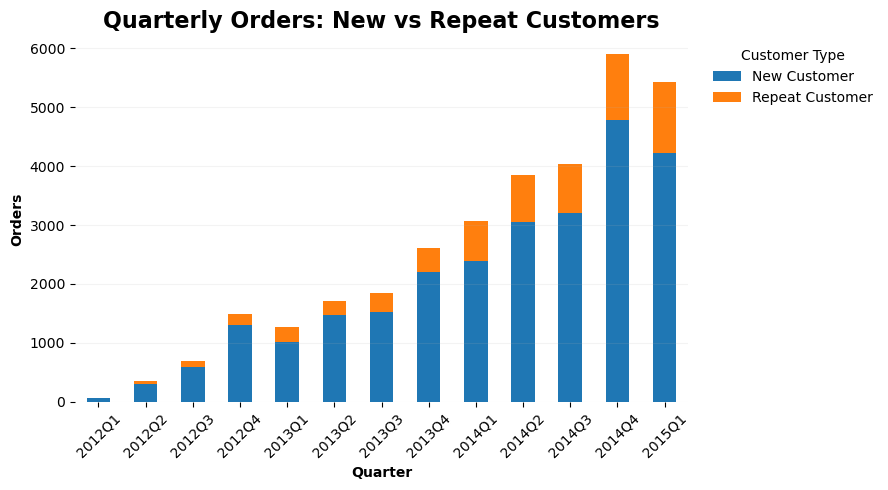

In [133]:
orders_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.xlabel("Quarter", fontweight='semibold')
plt.ylabel("Orders", fontweight='semibold')
plt.title("Quarterly Orders: New vs Repeat Customers",
         fontsize=16,
         fontweight='semibold')
plt.xticks(rotation=45)
plt.legend(title="Customer Type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon = False)
plt.grid(axis='y', alpha=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.tight_layout()
plt.show()


## Repeat Customer Contribution to Orders
- Repeat customers contribute a growing share of total orders over time.
- This indicates early customer lifetime value and improving retention economics.

“While new customers continue to drive growth, repeat customers contribute an increasing share of total orders. This indicates early customer lifetime value and a foundation for more efficient growth over time.”

If challenged:

“At this stage, we prioritize acquisition while retention improves naturally as the customer base expands.”

### “Growth is driven by continued customer acquisition, supported by steadily improving repeat engagement and purchase behavior.”

“We see consistent traffic growth driven by diversified acquisition channels. Users move through a healthy conversion funnel, translating into steadily growing revenue and profit. Our product portfolio balances scale and margin, with improving diversification over time. Revenue quality remains stable, and repeat customer engagement and orders are increasing — supporting long-term sustainability.”

In [134]:
orders_pivot.reset_index()

customer_type,quarter,New Customer,Repeat Customer
0,2012Q1,60.0,0.0
1,2012Q2,300.0,47.0
2,2012Q3,597.0,87.0
3,2012Q4,1309.0,186.0
4,2013Q1,1017.0,256.0
5,2013Q2,1467.0,250.0
6,2013Q3,1531.0,310.0
7,2013Q4,2210.0,406.0
8,2014Q1,2397.0,672.0
9,2014Q2,3060.0,788.0


# High level metrics

In [135]:
# total revenue
total_revenue= orders['price_usd'].sum()
millify(total_revenue,precision = 2)

'1.94M'

In [136]:
# Total sessions
total_sessions= website_sessions['website_session_id'].nunique()
millify(total_sessions,precision=2)

'472.87k'

In [137]:
# total refund orders
total_refund_orders= order_item_refunds['order_item_refund_id'].nunique()
millify(total_refund_orders,precision=2)

'1.73k'

In [138]:
website_sessions.columns

Index(['Unnamed: 0', 'website_session_id', 'created_at', 'user_id',
       'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content',
       'device_type', 'http_referer', 'year', 'quarter', 'channel',
       'channel_group', 'month', 'session_type'],
      dtype='object')

In [139]:
# new sessions
millify(
    website_sessions[website_sessions['is_repeat_session']==0]['website_session_id'].count(),
    precision=2)

'394.32k'

In [140]:
# Repeated sessions
millify(
    website_sessions[website_sessions['is_repeat_session']==1]['website_session_id'].count(),
    precision=2)

'78.55k'

In [141]:
total_orders= orders['order_id'].nunique()
total_revenue= orders['price_usd'].sum()
# avg order value
millify(total_revenue/total_orders,precision=2)

'59.99'

In [142]:
# refund rate
refund_rate = (total_refund_orders/total_orders)*100
millify(refund_rate,precision=2)

'5.36'

In [143]:
total_cogs = orders['cogs_usd'].sum()
millify(total_cogs,precision=2)

'722.37k'

In [144]:
millify(total_revenue,precision=2)

'1.94M'

In [145]:
refund_amount= order_item_refunds['refund_amount_usd'].sum()
refund_amount

np.float64(85338.69)

In [146]:
order_item_refunds

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99
...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99
1727,1728,2015-03-30 21:33:51,39671,32049,49.99
1728,1729,2015-03-31 19:59:48,39729,32090,49.99
1729,1730,2015-04-01 03:54:48,39717,32079,59.99


In [147]:
# gross profit
net_revenue= (total_revenue-refund_amount)
millify(net_revenue,precision=2)

'1.85M'

In [148]:
gross_profit=net_revenue-total_cogs
millify(gross_profit,precision=2)

'1.13M'

In [149]:
gross_profit_pct = (gross_profit)/net_revenue
print(f'{millify(gross_profit_pct*100,precision=2)} %')

61.02 %


In [150]:
# no of products
products['product_name'].nunique()

4

In [151]:
# avg page depth
total_pageview=website_pageviews['website_pageview_id'].nunique()
total_sessions = website_pageviews['website_session_id'].nunique()
avg_depth=total_pageview/total_sessions
round(avg_depth,2)

2.51

In [152]:
most_visited_page = (
    website_pageviews
    .groupby('pageview_url')['website_pageview_id']
    .count()
    .sort_values(ascending=False)
    .head(1)
)

page = most_visited_page.index[0].replace('/', '')
views = most_visited_page.iloc[0]

output = f"{page} {millify(views, precision=2)}"
output

'products 261.23k'

In [153]:
# total orders
millify(total_orders,precision=2)

'32.31k'

In [154]:
# item_sold
total_item_sold=orders['items_purchased'].sum()
millify(total_item_sold,precision=2)

'40.02k'

In [155]:
# refund amount
millify(total_refund,precision =2 )

'85.34k'

In [156]:
# total refund items
refund_items = order_item_refunds['order_item_id'].nunique()
refund_items

1731

In [157]:
order_web= orders.drop(columns=['created_at']).merge(website_sessions,on = 'website_session_id', how= 'right')
order_web

,order_id,website_session_id,user_id_x,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,year_x,quarter_x,month_x,Unnamed: 0,created_at,user_id_y,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,year_y,quarter_y,channel,channel_group,month_y,session_type
0,NaN,1,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,0,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,2012Q1,gsearch,GSearch Nonbrand,3,New
1,NaN,2,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,1,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,2012Q1,gsearch,GSearch Nonbrand,3,New
2,NaN,3,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,2,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,2012Q1,gsearch,GSearch Nonbrand,3,New
3,NaN,4,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,3,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012,2012Q1,gsearch,GSearch Nonbrand,3,New
4,NaN,5,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,4,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012,2012Q1,gsearch,GSearch Nonbrand,3,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472866,NaN,472867,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,472866,2015-03-19 07:49:25,394314,0,gsearch,brand,g_ad_2,desktop,https://www.gsearch.com,2015,2015Q1,gsearch,Brand Search,3,New
472867,NaN,472868,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,472867,2015-03-19 07:54:36,394315,0,bsearch,nonbrand,b_ad_1,mobile,https://www.bsearch.com,2015,2015Q1,bsearch,BSearch Nonbrand,3,New
472868,NaN,472869,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,472868,2015-03-19 07:55:40,394316,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2015,2015Q1,gsearch,GSearch Nonbrand,3,New
472869,NaN,472870,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,472869,2015-03-19 07:56:29,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2015,2015Q1,gsearch,GSearch Nonbrand,3,New


In [158]:
utm_df= order_web.groupby(['utm_source','utm_campaign'])[['website_session_id','order_id']].nunique().reset_index().rename(columns={
        'order_id': 'orders',
        'website_session_id': 'sessions'
    })
utm_df_search = utm_df[utm_df['utm_source'].isin(['gsearch', 'bsearch'])]
utm_df_search

,utm_source,utm_campaign,sessions,orders
0,bsearch,brand,7914,701
1,bsearch,nonbrand,54909,3818
2,gsearch,brand,33329,2511
3,gsearch,nonbrand,282706,18822


In [159]:
sessions_pivot = utm_df_search.pivot_table(
    index='utm_source',
    columns='utm_campaign',
    values='sessions',
    aggfunc='sum'
)
orders_by_channel = (
    utm_df_search
    .groupby('utm_source')['orders']
    .sum()
)
final_pivot = sessions_pivot.join(orders_by_channel).reset_index()
final_pivot

,utm_source,brand,nonbrand,orders
0,bsearch,7914,54909,4519
1,gsearch,33329,282706,21333


In [160]:
# gsearch
order_web['session_month'] =order_web['created_at'].dt.to_period('M')
ord=order_web[order_web['utm_source']=='gsearch'].groupby('order_month')['order_id'].nunique().reset_index(name='orders')
sess=order_web[order_web['utm_source']=='gsearch'].groupby('session_month')['website_session_id'].nunique().reset_index(name='sessions')
final_df = ord.merge(sess, left_on = 'order_month',right_on='session_month',how = 'left').drop(columns='session_month')
final_df

,order_month,orders,sessions
0,2012-03,60,1860
1,2012-04,92,3574
2,2012-05,97,3410
3,2012-06,121,3578
4,2012-07,145,3811
5,2012-08,184,4877
6,2012-09,188,4491
7,2012-10,234,5534
8,2012-11,417,9715
9,2012-12,333,7038


In [161]:
brand_gsearch = order_web[
    (order_web['utm_source'] == 'gsearch') &
    (order_web['utm_campaign'] == 'brand')
]

final_df1 = (
    brand_gsearch
    .groupby('session_month')
    .agg(
        sessions=('website_session_id', 'nunique'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

df1_pct=final_df1.assign(
    session_pct=lambda x: (x['sessions']/x['sessions'].sum()),
    orders_pct= lambda x: (x['orders']/x['orders'].sum()))
df1_pct.drop(columns=['sessions','orders'])

,session_month,session_pct,orders_pct
0,2012-03,0.000240,0.000000
1,2012-04,0.001950,0.002389
2,2012-05,0.003450,0.002389
3,2012-06,0.004171,0.002788
4,2012-07,0.004531,0.003584
5,2012-08,0.006121,0.003982
6,2012-09,0.007921,0.006372
7,2012-10,0.010111,0.005974
8,2012-11,0.013742,0.008363
9,2012-12,0.016292,0.013939


In [162]:
nonbrand_gsearch = order_web[
    (order_web['utm_source'] == 'gsearch') &
    (order_web['utm_campaign'] == 'nonbrand')
]

final_df2 = (
    nonbrand_gsearch
    .groupby('session_month')
    .agg(
        sessions=('website_session_id', 'nunique'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

df2_pct= final_df2.assign(
    session_pct=lambda x:(x['sessions']/x['sessions'].sum()),
    order_pct=lambda x:(x['orders']/x['orders'].sum()))
df2_pct.drop(columns=['sessions','orders'])

,session_month,session_pct,order_pct
0,2012-03,0.006551,0.003188
1,2012-04,0.012412,0.004569
2,2012-05,0.011655,0.004835
3,2012-06,0.012165,0.006057
4,2012-07,0.012946,0.007226
5,2012-08,0.016530,0.009245
6,2012-09,0.014952,0.009138
7,2012-10,0.018383,0.011635
8,2012-11,0.032744,0.021039
9,2012-12,0.022974,0.015833


# Yearly revenue

In [163]:
orders

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,order_month,year,quarter,month
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012-03,2012,2012Q1,3
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012-03,2012,2012Q1,3
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012-03,2012,2012Q1,3
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012-03,2012,2012Q1,3
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012-03,2012,2012Q1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32308,32309,2015-03-19 03:58:12,472795,394255,1,1,49.99,19.49,2015-03,2015,2015Q1,3
32309,32310,2015-03-19 04:10:43,472798,394257,4,1,29.99,9.49,2015-03,2015,2015Q1,3
32310,32311,2015-03-19 05:27:28,472809,394268,2,2,89.98,31.98,2015-03,2015,2015Q1,3
32311,32312,2015-03-19 05:35:57,472814,394273,4,1,29.99,9.49,2015-03,2015,2015Q1,3


In [164]:
orders.groupby('year').price_usd.sum().reset_index(name='total_revenue')

,year,total_revenue
0,2012,129274.14
1,2013,393247.87
2,2014,1075612.19
3,2015,340375.55


# monthly trend 

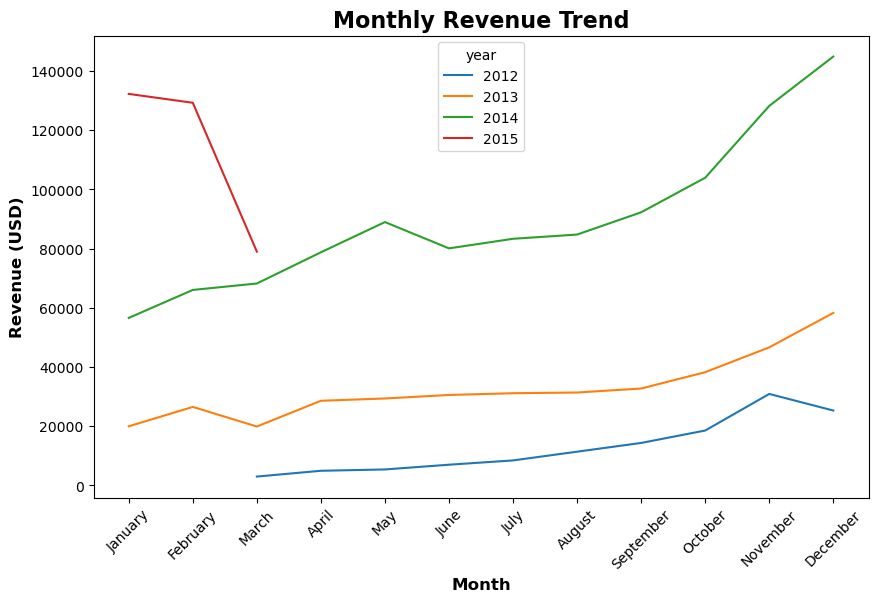

In [165]:
orders['month']= orders['created_at'].dt.month
orders['month_name']= orders['created_at'].dt.month_name()
monthly_trend= (orders.groupby(['year','month','month_name'])['price_usd']
                .sum()
                .reset_index(name='total_revenue')
                .sort_values(['year','month'])
)
pivot_df=monthly_trend.pivot(
    index='month_name',
    columns='year',
    values='total_revenue'
)
month_order=['January', 'February', 'March', 'April', 'May', 'June',
             'July', 'August', 'September', 'October', 'November', 'December']
pivot_df = pivot_df.reindex(month_order)
ax=pivot_df.plot(kind='line', figsize=(10, 6))
ax.set_title("Monthly Revenue Trend", fontsize=16, fontweight='semibold')
ax.set_xlabel("Month", fontsize=12, fontweight='semibold')
ax.set_ylabel("Revenue (USD)", fontsize=12, fontweight='semibold')  
ax.set_xticks(range(len(pivot_df)))
ax.set_xticklabels(pivot_df.index, rotation=45)
plt.show()
              

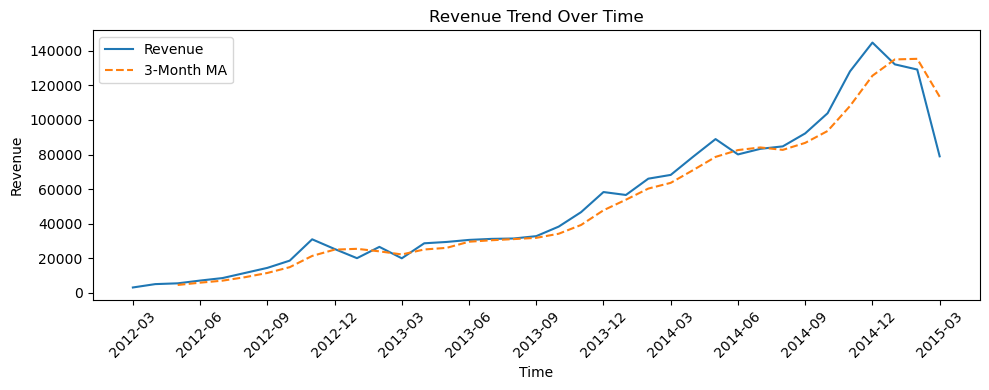

In [166]:
import matplotlib.pyplot as plt

# Create a proper time index
orders['year_month'] = orders['created_at'].dt.to_period('M').astype(str)

# Aggregate revenue by time
trend_df = (
    orders.groupby('year_month')['price_usd']
    .sum()
    .reset_index()
)

# Moving average
trend_df['ma_3'] = trend_df['price_usd'].rolling(3).mean()

# Plot trend
ax = trend_df.plot(
    x='year_month',
    y='price_usd',
    kind='line',
    figsize=(10, 4),
    label='Revenue'
)

trend_df.plot(
    x='year_month',
    y='ma_3',
    kind='line',
    linestyle='--',
    ax=ax,
    label='3-Month MA'
)

ax.set_title('Revenue Trend Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Revenue')
ax.set_xticks(range(0, len(trend_df), 3))
ax.set_xticklabels(trend_df['year_month'][::3], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

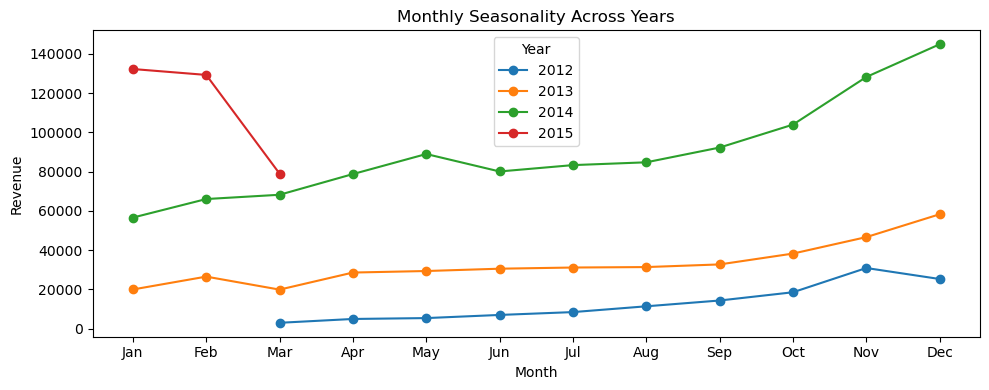

In [167]:
# Prepare seasonal data
orders['year'] = orders['created_at'].dt.year
orders['month'] = orders['created_at'].dt.month
orders['month_name'] = orders['created_at'].dt.month_name()

seasonal_df = (
    orders.groupby(['year', 'month', 'month_name'])['price_usd']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)

# Pivot for plotting
pivot_seasonal = seasonal_df.pivot(
    index='month',
    columns='year',
    values='price_usd'
)

# Plot seasonality
ax = pivot_seasonal.plot(
    kind='line',
    marker='o',
    figsize=(10, 4)
)

ax.set_title('Monthly Seasonality Across Years')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# CAGR Calculation

In [168]:
monthly_revenue = (
    orders.groupby('year_month')['price_usd']
    .sum()
    .sort_index()
)
monthly_revenue.index=pd.to_datetime(monthly_revenue.index)
rolling_12m_revenue=monthly_revenue.rolling(12).sum()
rolling_12m_revenue

year_month
2012-03-01           NaN
2012-04-01           NaN
2012-05-01           NaN
2012-06-01           NaN
2012-07-01           NaN
2012-08-01           NaN
2012-09-01           NaN
2012-10-01           NaN
2012-11-01           NaN
2012-12-01           NaN
2013-01-01           NaN
2013-02-01     175755.26
2013-03-01     192652.01
2013-04-01     216287.47
2013-05-01     240252.84
2013-06-01     263798.31
2013-07-01     286493.96
2013-08-01     306470.16
2013-09-01     324846.68
2013-10-01     344543.01
2013-11-01     360280.21
2013-12-01     393247.87
2014-01-01     429850.66
2014-02-01     469348.16
2014-03-01     517641.74
2014-04-01     567782.70
2014-05-01     627353.68
2014-06-01     676860.86
2014-07-01     729005.45
2014-08-01     782347.61
2014-09-01     841856.45
2014-10-01     907519.81
2014-11-01     989051.77
2014-12-01    1075612.19
2015-01-01    1151254.84
2015-02-01    1214455.26
2015-03-01    1225216.60
Name: price_usd, dtype: float64

In [169]:
begining_value= 175755.26
ending_value= 1225216.60
year = 3
cagr = (ending_value / begining_value) ** (1 / year) - 1
print(f'{round(cagr * 100,2)}%')

91.03%


### “Over the last three years, the business has grown revenue at an average rate of ~91% per year on a trailing 12-month basis, despite starting mid-year and accounting for seasonality.”

91% CAGR over 3 years is a strong growth rate, especially for a business that started mid-year and has to navigate seasonality. This indicates that the company has been able to rapidly scale its revenue while managing the challenges of a new market entry and fluctuating demand throughout the year.

# gsearch & bsearch nonbrand orders

In [170]:
nonbrand_gsearch = website_sessions[(website_sessions['utm_source']=='gsearch') & (website_sessions['utm_campaign']=='nonbrand')]
nonbrand_bsearch = website_sessions[(website_sessions['utm_source']=='bsearch') & (website_sessions['utm_campaign']=='nonbrand')]
nonbrand_gsearch_orders=orders[['order_id','website_session_id']].merge(nonbrand_gsearch,on= 'website_session_id',how = 'inner')
nonbrand_bsearch_orders= orders[['order_id','website_session_id']].merge(nonbrand_bsearch,on='website_session_id',how='inner')
nonbrand_gsearch_total_orders= nonbrand_gsearch_orders.groupby('quarter')['order_id'].nunique().reset_index(name='orders')
nonbrand_bsearch_total_orders= nonbrand_bsearch_orders.groupby('quarter')['order_id'].nunique().reset_index(name='orders')
nonbrand_gsearch_total_orders

,quarter,orders
0,2012Q1,60
1,2012Q2,291
2,2012Q3,482
3,2012Q4,913
4,2013Q1,766
5,2013Q2,1114
6,2013Q3,1132
7,2013Q4,1657
8,2014Q1,1667
9,2014Q2,2208


In [171]:
nonbrand_bsearch_total_orders

,quarter,orders
0,2012Q3,82
1,2012Q4,311
2,2013Q1,183
3,2013Q2,237
4,2013Q3,245
5,2013Q4,291
6,2014Q1,344
7,2014Q2,427
8,2014Q3,434
9,2014Q4,683


# billing 1 vs billing 2 comparison

In [172]:
billing2_launch_date=website_pageviews[website_pageviews['pageview_url']=='/billing-2']['created_at'].min()
billing2_launch_date

Timestamp('2012-09-10 00:13:05')

In [173]:
billing_pages=website_pageviews[website_pageviews['pageview_url'].isin(['/billing','/billing-2'])]
billing_orders=billing_pages.merge(orders[['order_id','website_session_id','price_usd']],on='website_session_id',how='left')

In [174]:
billing_orders['period'] = billing_orders['created_at'].apply(lambda x: 'before' if x < pd.Timestamp('2012-09-10') else 'after')

In [175]:
before_revenue = (billing_orders[billing_orders['period'] == 'before']
                  .groupby('pageview_url')['price_usd']
                  .sum()
                  .reset_index(name='before_test_revenue')
)
after_revenue=(billing_orders[billing_orders['period'] == 'after']
               .groupby('pageview_url')['price_usd']
               .sum()
               .reset_index(name='after_test_revenue')
               )
final_revenue= before_revenue.merge(after_revenue, on='pageview_url', how='outer')
final_revenue

,pageview_url,before_test_revenue,after_test_revenue
0,/billing,43491.3,37492.50
1,/billing-2,NaN,1857525.95


# billing conversion rate

In [176]:
# calculate sessions for billing pages
sessions=(
    billing_orders
    .groupby(['pageview_url','period'])['website_session_id']
    .nunique()
    .reset_index(name='sessions')
        )
sessions

,pageview_url,period,sessions
0,/billing,after,1663
1,/billing,before,1954
2,/billing-2,after,48441


In [177]:
# calculate orders per billing page
orders_count=(
    billing_orders[billing_orders['order_id'].notna()]
    .groupby(['pageview_url','period'])['website_session_id']
    .nunique()
    .reset_index(name='orders')
)
orders_count

,pageview_url,period,orders
0,/billing,after,750
1,/billing,before,870
2,/billing-2,after,30693


In [178]:
# merge and calculate conversion rate
conversion = sessions.merge(orders_count, on=['pageview_url','period'], how='left')
conversion['conversion_rate'] = conversion['orders'] / conversion['sessions'] * 100
conversion

,pageview_url,period,sessions,orders,conversion_rate
0,/billing,after,1663,750,45.099218
1,/billing,before,1954,870,44.524053
2,/billing-2,after,48441,30693,63.361615


In [179]:
before_conversion = (
    conversion[conversion['period'] == 'before'][['pageview_url','conversion_rate']]
    .rename(columns={'conversion_rate': 'before_conversion_rate'})
)
after_conversion=(
    conversion[conversion['period'] == 'after'][['pageview_url','conversion_rate']]
    .rename(columns={'conversion_rate': 'after_conversion_rate'})   
)
final_conversion = before_conversion.merge(after_conversion, on='pageview_url', how='outer')
final_conversion

,pageview_url,before_conversion_rate,after_conversion_rate
0,/billing,44.524053,45.099218
1,/billing-2,NaN,63.361615


In [180]:
website_pageviews

,website_pageview_id,created_at,website_session_id,pageview_url,year,month
0,1,2012-03-19 08:04:16,1,/home,2012,3
1,2,2012-03-19 08:16:49,2,/home,2012,3
2,3,2012-03-19 08:26:55,3,/home,2012,3
3,4,2012-03-19 08:37:33,4,/home,2012,3
4,5,2012-03-19 09:00:55,5,/home,2012,3
...,...,...,...,...,...,...
1188115,1188116,2015-03-19 07:55:40,472869,/lander-3,2015,3
1188117,1188118,2015-03-19 07:56:29,472870,/lander-5,2015,3
1188118,1188119,2015-03-19 07:57:22,472870,/products,2015,3
1188120,1188121,2015-03-19 07:58:13,472870,/the-original-mr-fuzzy,2015,3


# first eight month performance and conversion rate

In [181]:
first_8months=website_pageviews[website_pageviews['created_at'] < pd.Timestamp('2012-11-01')]
first_8months_sessions=first_8months.groupby(['year','month'])['website_session_id'].nunique().reset_index(name='sessions')
first_8months_sessions

,year,month,sessions
0,2012,3,1879
1,2012,4,3735
2,2012,5,3736
3,2012,6,3965
4,2012,7,4249
5,2012,8,6098
6,2012,9,6546
7,2012,10,8183


In [182]:
first_8months_performance_combine= first_8months.merge(orders[['order_id','website_session_id']], on='website_session_id', how='left')
first_8months_performance_orders= first_8months_performance_combine[first_8months_performance_combine['order_id'].notna()].groupby(['year','month'])['website_session_id'].nunique().reset_index(name='orders')
first_8months_final= first_8months_performance_orders.merge(first_8months_sessions, on=['year','month'], how='left')
first_8months_final['conversion_rate']= first_8months_final['orders']/first_8months_final['sessions']*100
first_8months_final_ppt_output= first_8months_final[['year','month','orders','conversion_rate']]
first_8months_final_ppt_output

,year,month,orders,conversion_rate
0,2012,3,60,3.193188
1,2012,4,99,2.650602
2,2012,5,108,2.890792
3,2012,6,140,3.530895
4,2012,7,169,3.977406
5,2012,8,228,3.738931
6,2012,9,287,4.384357
7,2012,10,371,4.533790


In [183]:
first_8months_final

,year,month,orders,sessions,conversion_rate
0,2012,3,60,1879,3.193188
1,2012,4,99,3735,2.650602
2,2012,5,108,3736,2.890792
3,2012,6,140,3965,3.530895
4,2012,7,169,4249,3.977406
5,2012,8,228,6098,3.738931
6,2012,9,287,6546,4.384357
7,2012,10,371,8183,4.533790


# /homepage and lander-1 performance

In [184]:
first_page=(
    website_pageviews
    .sort_values(['website_session_id','created_at'])
            .groupby('website_session_id')
    .first()
    .reset_index()[['website_session_id','pageview_url']]
)
lander_sessions=website_sessions.merge(
    first_page,
    on='website_session_id',
    how='inner'
)
test_sessions = lander_sessions[
    (lander_sessions['utm_source']=='gsearch') &
    (lander_sessions['utm_campaign'] == 'nonbrand') &
    (lander_sessions['pageview_url'].isin(['/home','/lander-1']))
]
daily_test_split=(
    test_sessions
    .groupby([
        test_sessions['created_at'].dt.floor('D'),
        'pageview_url'
    ])['website_session_id']
    .nunique()
    .unstack()
    .fillna(0)
)
test_window= daily_test_split[
    (daily_test_split['/home']>0)&
    (daily_test_split['/lander-1']>0)
]
test_end=test_window.index.max()
test_start=test_window.index.min()
test_start,test_end

(Timestamp('2012-06-19 00:00:00'), Timestamp('2012-07-29 00:00:00'))

In [185]:
final_test_sessions= lander_sessions[
    (lander_sessions['utm_source']=='gsearch') &
    (lander_sessions['utm_campaign'] == 'nonbrand') &
    (lander_sessions['pageview_url'].isin(['/home','/lander-1'])) &
    (lander_sessions['created_at']>=test_start) &
    (lander_sessions['created_at'] <= test_end)
]
sessions=(
    final_test_sessions
    .groupby('pageview_url')['website_session_id']
    .nunique()
    .reset_index(name='sessions')
)
test_orders= orders.merge(
    final_test_sessions[['website_session_id','pageview_url']],
    on='website_session_id',
    how='inner'
)
orders_count= (
    test_orders
    .groupby('pageview_url')['order_id']
    .nunique()
    .reset_index(name='orders')
)
results=sessions.merge(orders_count, on='pageview_url')
results['CVR']=results['orders']/results['sessions'] * 100
results
    

,pageview_url,sessions,orders,CVR
0,/home,2295,74,3.224401
1,/lander-1,2350,94,4.000000


In [186]:
post_test_lander= lander_sessions[
    (lander_sessions['utm_source']=='gsearch') &
    (lander_sessions['utm_campaign'] == 'nonbrand') &
    (lander_sessions['created_at'] > test_end)
]
post_test_sessions= post_test_lander['website_session_id'].nunique()
post_test_orders= orders.merge(
    post_test_lander['website_session_id'],
    on = 'website_session_id',
    how= 'inner'
)
aov= post_test_orders['price_usd'].sum()/post_test_orders['order_id'].nunique()
post_test_sessions, aov

(267384, np.float64(59.99122247656421))

# Baseline CVR

In [187]:
baseline= lander_sessions[
    (lander_sessions['utm_source'] == 'gsearch') &
    (lander_sessions['utm_campaign']=='nonbrand') &
    (lander_sessions['pageview_url']=='/home') &
    (lander_sessions['created_at']< test_start)
]
baseline_sessions= baseline['website_session_id'].nunique()
baseline_orders=orders.merge(baseline[['website_session_id']],on= 'website_session_id').order_id.nunique()
baseline_cvr=baseline_orders/baseline_sessions*100
baseline_cvr

2.865973588086541

# analyse the traffic source and its respective lander

In [188]:
website_pageviews.pageview_url.unique()

array(['/home', '/products', '/the-original-mr-fuzzy', '/cart',
       '/shipping', '/billing', '/thank-you-for-your-order', '/lander-1',
       '/billing-2', '/the-forever-love-bear', '/lander-2', '/lander-3',
       '/the-birthday-sugar-panda', '/lander-4', '/lander-5',
       '/the-hudson-river-mini-bear'], dtype=object)

In [189]:
website_pageviews[website_pageviews['pageview_url'].isin(['/lander-1','/lander-2'])]

,website_pageview_id,created_at,website_session_id,pageview_url,year,month
23503,23504,2012-06-19 00:35:54,11683,/lander-1,2012,6
23505,23506,2012-06-19 01:02:38,11685,/lander-1,2012,6
23506,23507,2012-06-19 01:31:57,11686,/lander-1,2012,6
23510,23511,2012-06-19 02:14:55,11689,/lander-1,2012,6
23514,23515,2012-06-19 04:08:52,11691,/lander-1,2012,6
...,...,...,...,...,...,...
1003987,1003988,2014-12-27 21:43:28,405513,/lander-2,2014,12
1003993,1003994,2014-12-27 21:52:17,405515,/lander-2,2014,12
1004018,1004019,2014-12-27 22:26:23,405524,/lander-2,2014,12
1004027,1004028,2014-12-27 22:31:01,405530,/lander-2,2014,12


In [190]:
first_page=(
    website_pageviews
    .sort_values(['website_session_id','created_at'])
            .groupby('website_session_id')
    .first()
    .reset_index()[['website_session_id','pageview_url']]
)
lander_compaign_map=website_sessions.merge(
    first_page,
    on='website_session_id',
    how='inner'
)
lander_summary=lander_compaign_map.groupby(
    ['utm_source', 'utm_campaign','pageview_url']
)['website_session_id'].nunique().reset_index(name='sessions')
ppt_ready= (
    lander_summary
    .groupby(['utm_source', 'utm_campaign'])
    .agg(landing_pages_used=('pageview_url',lambda x: ','.join(sorted(x.unique()))),
         total_sessions=('sessions','sum'))
).reset_index()
ppt_ready

,utm_source,utm_campaign,landing_pages_used,total_sessions
0,bsearch,brand,/home,7914
1,bsearch,nonbrand,"/lander-1,/lander-2,/lander-3,/lander-4,/lander-5",54909
2,gsearch,brand,/home,33329
3,gsearch,nonbrand,"/home,/lander-1,/lander-2,/lander-3,/lander-4,/lander-5",282706
4,socialbook,desktop_targeted,/lander-2,5590
5,socialbook,pilot,"/lander-2,/lander-3",5095


In [191]:
website_sessions.channel.unique()

array(['gsearch', 'direct', 'organic', 'bsearch', 'socialbook'],
      dtype=object)

In [192]:
# downloading updated dataset
website_sessions.to_parquet('website_sessions.parquet', index= False)
orders.to_parquet('orders.parquet',index= False)
order_item_refunds.to_parquet('order_item_refunds.parquet',index= False)
order_items.to_parquet('order_items.parquet',index=False)
website_pageviews.to_parquet('website_pageviews.parquet',index=False)
products.to_parquet('products.parquet',index=False)